# Rossmann Store Sales — Explainable DSS for Retail Demand Forecasting

**BSc Computer Science — Final-Year Thesis**
*Explainable Sales Forecasting with AI-Generated Retail Recommendations: A Rossmann Case Study*


In [6]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import joblib
from pathlib import Path

warnings.filterwarnings("ignore")

## 1. Data Loading, Merging, and Initial Understanding

Load the Rossmann Store Sales dataset, merge historical sales records with store-level metadata, and perform initial inspection to understand structure, missing values, and temporal coverage.

In [7]:
# Load dataset files
DATA_DIR = Path("data")

train = pd.read_csv(DATA_DIR / "train.csv")
store = pd.read_csv(DATA_DIR / "store.csv")

print("Train shape:", train.shape)
print("Store shape:", store.shape)

Train shape: (1017209, 9)
Store shape: (1115, 10)


In [8]:
# Inspect raw datasets
for name, frame in [("Train", train), ("Store", store)]:
    print(f"\n{'─'*40} {name} {'─'*40}")
    display(frame.head(3))


──────────────────────────────────────── Train ────────────────────────────────────────


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1



──────────────────────────────────────── Store ────────────────────────────────────────


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"


In [9]:
# Missing values summary
for name, frame in [("Train", train), ("Store", store)]:
    missing = frame.isnull().sum()
    missing = missing[missing > 0]

    if len(missing):
        print(f"\n{name} — missing values:")
        display(
            missing.to_frame("Count")
            .assign(
                Pct=lambda d: (
                    d["Count"] / len(frame) * 100
                ).round(2)
            )
        )
    else:
        print(f"\n{name} — no missing values.")


Train — no missing values.

Store — missing values:


,Count,Pct
CompetitionDistance,3,0.27
CompetitionOpenSinceMonth,354,31.75
CompetitionOpenSinceYear,354,31.75
Promo2SinceWeek,544,48.79
Promo2SinceYear,544,48.79
PromoInterval,544,48.79


In [10]:
# Duplicate rows
for name, frame in [("Train", train), ("Store", store)]:
    print(
        f"Duplicate rows in {name}: "
        f"{frame.duplicated().sum()}"
    )

Duplicate rows in Train: 0
Duplicate rows in Store: 0


In [17]:
# Merge sales data with store information
df = train.merge(store, on="Store", how="left")

# Convert Date to datetime and sort chronologically
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

print("Merged shape:", df.shape)
print("Unique stores:", df["Store"].nunique())
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Missing StoreType after merge:", df["StoreType"].isna().sum())

Merged shape: (1017209, 18)
Unique stores: 1115
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Missing StoreType after merge: 0


In [19]:
# Inspect sales target and zero-sales observations
display(df["Sales"].describe())

zero_sales = (df["Sales"] == 0).sum()

print(f"Zero-sales rows: {zero_sales}")
print(f"Percentage: {zero_sales / len(df) * 100:.2f}%")

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

Zero-sales rows: 172871
Percentage: 16.99%


## 2. Data Cleaning and Leakage-Safe Preprocessing

The merged dataset is cleaned by correcting data types, handling missing values, removing unsuitable observations, and excluding features that could introduce data leakage.

**Key decisions:**

- `Customers` is removed because customer counts are only fully known after the trading period and would introduce target leakage when forecasting future sales.
- Closed-store observations (Open = 0) are excluded because zero sales on those days result from the store not trading. A further 54 open-store observations with zero sales are also excluded because they are rare anomalous cases and are not representative of normal operating sales.
- Missing `CompetitionDistance` values occur for only **3 stores (0.27%)** and are imputed using the median, which is less sensitive to extreme distances than the mean.
- Missing competition and `Promo2` timing fields are handled according to whether the corresponding information is known or applicable.

In [20]:
# Create a working copy for cleaning
df_clean = df.copy()

print("Shape before cleaning:", df_clean.shape)

Shape before cleaning: (1017209, 18)


In [36]:
# Standardise StateHoliday values
df_clean["StateHoliday"] = (
    df_clean["StateHoliday"]
    .astype(str)
    .replace({"0": "none"})
)

print("StateHoliday value counts:")
print(df_clean["StateHoliday"].value_counts())

StateHoliday value counts after fix:
StateHoliday
none    986159
a        20260
b         6690
c         4100
Name: count, dtype: int64


In [21]:
# Impute missing CompetitionDistance values using the median
print(
    "Missing CompetitionDistance before:",
    df_clean["CompetitionDistance"].isnull().sum()
)

competition_median = df_clean["CompetitionDistance"].median()

df_clean["CompetitionDistance"] = (
    df_clean["CompetitionDistance"]
    .fillna(competition_median)
)

print(f"Median used for imputation: {competition_median:,.0f} m")
print(
    "Missing CompetitionDistance after:",
    df_clean["CompetitionDistance"].isnull().sum()
)

Missing CompetitionDistance before: 2642
Median used for imputation: 2,330 m
Missing CompetitionDistance after: 0


In [22]:
# Handle missing competition opening information
df_clean["CompetitionOpenKnown"] = (
    df_clean["CompetitionOpenSinceMonth"].notna()
    & df_clean["CompetitionOpenSinceYear"].notna()
).astype(int)

df_clean["CompetitionOpenSinceMonth"] = (
    df_clean["CompetitionOpenSinceMonth"].fillna(0)
)

df_clean["CompetitionOpenSinceYear"] = (
    df_clean["CompetitionOpenSinceYear"].fillna(0)
)

print("CompetitionOpenKnown value counts:")
print(df_clean["CompetitionOpenKnown"].value_counts())

CompetitionOpenKnown value counts:
CompetitionOpenKnown
1    693861
0    323348
Name: count, dtype: int64


In [23]:
# Handle missing Promo2 information
df_clean["Promo2SinceWeek"] = (
    df_clean["Promo2SinceWeek"].fillna(0)
)

df_clean["Promo2SinceYear"] = (
    df_clean["Promo2SinceYear"].fillna(0)
)

df_clean["PromoInterval"] = (
    df_clean["PromoInterval"].fillna("none")
)

print("PromoInterval value counts:")
print(df_clean["PromoInterval"].value_counts())

PromoInterval value counts:
PromoInterval
none                508031
Jan,Apr,Jul,Oct     293122
Feb,May,Aug,Nov     118596
Mar,Jun,Sept,Dec     97460
Name: count, dtype: int64


In [28]:
#  Remove closed-store and zero-sales rows 
print("Shape before removing closed/zero-sales rows:", df_clean.shape)
print("Zero-sales rows before:", (df_clean['Sales'] == 0).sum())

df_clean = df_clean[(df_clean['Open'] == 1) & (df_clean['Sales'] > 0)].copy()

print("Shape after  removing closed/zero-sales rows:", df_clean.shape)
print("Zero-sales rows after :", (df_clean['Sales'] == 0).sum())

Shape before removing closed/zero-sales rows: (1017209, 19)
Zero-sales rows before: 172871
Shape after  removing closed/zero-sales rows: (844338, 19)
Zero-sales rows after : 0


In [29]:
# Remove leakage-risk feature
# Customers is only fully known after the trading period, so using it
# would introduce future information into the sales forecast.
df_clean.drop(columns=["Customers"], inplace=True)

print("\nFinal cleaned dataset summary:")
print(f"Shape      : {df_clean.shape}")
print(f"Date range : {df_clean['Date'].min()} to {df_clean['Date'].max()}")
print(f"Stores     : {df_clean['Store'].nunique()}")
print(f"Missing    : {df_clean.isnull().sum().sum()} values")

assert df_clean.isnull().sum().sum() == 0
assert "Customers" not in df_clean.columns


Final cleaned dataset summary:
Shape      : (844338, 18)
Date range : 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Stores     : 1115
Missing    : 0 values


## 3. Time-Based Feature Engineering

Calendar-based features are derived from the `Date` column to capture temporal patterns in sales.

These features depend only on the known calendar date and therefore do not use future sales information or introduce target leakage.

In [30]:
# Create calendar-based time features
iso = df_clean["Date"].dt.isocalendar()

df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["WeekOfYear"] = iso.week.astype(int)
df_clean["Quarter"] = df_clean["Date"].dt.quarter
df_clean["IsWeekend"] = df_clean["DayOfWeek"].isin([6, 7]).astype(int)
df_clean["IsMonthStart"] = df_clean["Date"].dt.is_month_start.astype(int)
df_clean["IsMonthEnd"] = df_clean["Date"].dt.is_month_end.astype(int)

df_clean["YearMonth"] = (
    df_clean["Date"].dt.to_period("M").astype(str)
)

df_clean["YearWeek"] = (
    iso.year.astype(str)
    + "-W"
    + iso.week.astype(str).str.zfill(2)
)

print("Time features created. Shape:", df_clean.shape)

display(
    df_clean[
        [
            "Date",
            "Year",
            "Month",
            "WeekOfYear",
            "Quarter",
            "IsWeekend",
            "YearWeek",
        ]
    ].head(5)
)

Time features created. Shape: (844338, 27)


,Date,Year,Month,WeekOfYear,Quarter,IsWeekend,YearWeek
1,2013-01-02,2013,1,1,1,0,2013-W01
2,2013-01-03,2013,1,1,1,0,2013-W01
3,2013-01-04,2013,1,1,1,0,2013-W01
4,2013-01-05,2013,1,1,1,1,2013-W01
6,2013-01-07,2013,1,2,1,0,2013-W02


## 4. Weekly and Monthly Forecasting Dataset Creation

The cleaned daily records are aggregated into separate weekly and monthly store-level datasets for forecasting.

- Sales are summed within each forecasting period.
- Operational and holiday-related variables are aggregated as counts across the period.
- Store-level metadata is carried forward using the first value because these attributes remain constant within each store-period.

In [31]:
# Create weekly and monthly period keys
df_clean["WeekStartDate"] = (
    df_clean["Date"]
    - pd.to_timedelta(df_clean["Date"].dt.dayofweek, unit="D")
)

df_clean["MonthStartDate"] = (
    df_clean["Date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print(
    "WeekStartDate range:",
    df_clean["WeekStartDate"].min(),
    "to",
    df_clean["WeekStartDate"].max()
)

print(
    "MonthStartDate range:",
    df_clean["MonthStartDate"].min(),
    "to",
    df_clean["MonthStartDate"].max()
)

WeekStartDate range: 2012-12-31 00:00:00 to 2015-07-27 00:00:00
MonthStartDate range: 2013-01-01 00:00:00 to 2015-07-01 00:00:00


In [35]:
# Shared aggregation rules
common_agg = {
    "Open": "sum",
    "Promo": "sum",
    "SchoolHoliday": "sum",
    "IsWeekend": "sum",
    "IsMonthStart": "sum",
    "IsMonthEnd": "sum",
    "StateHoliday": lambda x: (x != "none").sum(),
    "Year": "first",
    "Month": "first",
    "Quarter": "first",
    "StoreType": "first",
    "Assortment": "first",
    "CompetitionDistance": "first",
    "CompetitionOpenKnown": "first",
    "CompetitionOpenSinceMonth": "first",
    "CompetitionOpenSinceYear": "first",
    "Promo2": "first",
    "Promo2SinceWeek": "first",
    "Promo2SinceYear": "first",
    "PromoInterval": "first",
}

rename_agg = {
    "Open": "OpenDays",
    "Promo": "PromoDays",
    "SchoolHoliday": "SchoolHolidayDays",
    "IsWeekend": "WeekendDays",
    "IsMonthStart": "MonthStartDays",
    "IsMonthEnd": "MonthEndDays",
    "StateHoliday": "StateHolidayDays",
}

# Weekly aggregation
weekly_df = (
    df_clean
    .groupby(["Store", "WeekStartDate"], as_index=False)
    .agg({
        "Sales": "sum",
        "WeekOfYear": "first",
        **common_agg
    })
    .rename(columns={
        "Sales": "WeeklySales",
        **rename_agg
    })
    .sort_values(["Store", "WeekStartDate"])
    .reset_index(drop=True)
)

# Monthly aggregation
monthly_df = (
    df_clean
    .groupby(["Store", "MonthStartDate"], as_index=False)
    .agg({
        "Sales": "sum",
        **common_agg
    })
    .rename(columns={
        "Sales": "MonthlySales",
        **rename_agg
    })
    .sort_values(["Store", "MonthStartDate"])
    .reset_index(drop=True)
)

# Sequential period index within each store
weekly_df["TimeIndex"] = (
    weekly_df.groupby("Store").cumcount() + 1
)

monthly_df["TimeIndex"] = (
    monthly_df.groupby("Store").cumcount() + 1
)

display(weekly_df.head(3))
display(monthly_df.head(3))

,Store,WeekStartDate,WeeklySales,WeekOfYear,OpenDays,PromoDays,SchoolHolidayDays,WeekendDays,MonthStartDays,MonthEndDays,...,Assortment,CompetitionDistance,CompetitionOpenKnown,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,TimeIndex
0,1,2012-12-31,19340,1,4,0,4,1,0,0,...,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,1
1,1,2013-01-07,32952,2,6,5,5,1,0,0,...,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,2
2,1,2013-01-14,25978,3,6,0,0,1,0,0,...,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,3


,Store,MonthStartDate,MonthlySales,OpenDays,PromoDays,SchoolHolidayDays,WeekendDays,MonthStartDays,MonthEndDays,StateHolidayDays,...,Assortment,CompetitionDistance,CompetitionOpenKnown,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,TimeIndex
0,1,2013-01-01,128431,26,10,9,4,0,1,26,...,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,1
1,1,2013-02-01,125271,24,10,0,4,1,1,24,...,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,2
2,1,2013-03-01,145169,25,14,4,5,1,0,25,...,a,1270.0,1,9.0,2008.0,0,0.0,0.0,none,3


In [34]:
# Validate weekly and monthly datasets
for label, frame, date_col in [
    ("Weekly", weekly_df, "WeekStartDate"),
    ("Monthly", monthly_df, "MonthStartDate"),
]:
    print(f"\n{label} dataset:")
    print(f"Shape   : {frame.shape}")
    print(f"Stores  : {frame['Store'].nunique()}")
    print(f"Periods : {frame[date_col].nunique()}")
    print(f"Range   : {frame[date_col].min()} to {frame[date_col].max()}")
    print(f"Missing : {frame.isnull().sum().sum()}")


Weekly dataset:
Shape   : (145808, 25)
Stores  : 1115
Periods : 135
Range   : 2012-12-31 00:00:00 to 2015-07-27 00:00:00
Missing : 0

Monthly dataset:
Shape   : (33465, 24)
Stores  : 1115
Periods : 31
Range   : 2013-01-01 00:00:00 to 2015-07-01 00:00:00
Missing : 0


## 5.  Exploratory Data Analysis

A focused exploratory analysis is performed on the aggregated datasets to examine temporal sales patterns and the effects of promotions and holidays.

The analysis is limited to patterns relevant to the forecasting features and model development used in the final DSS.

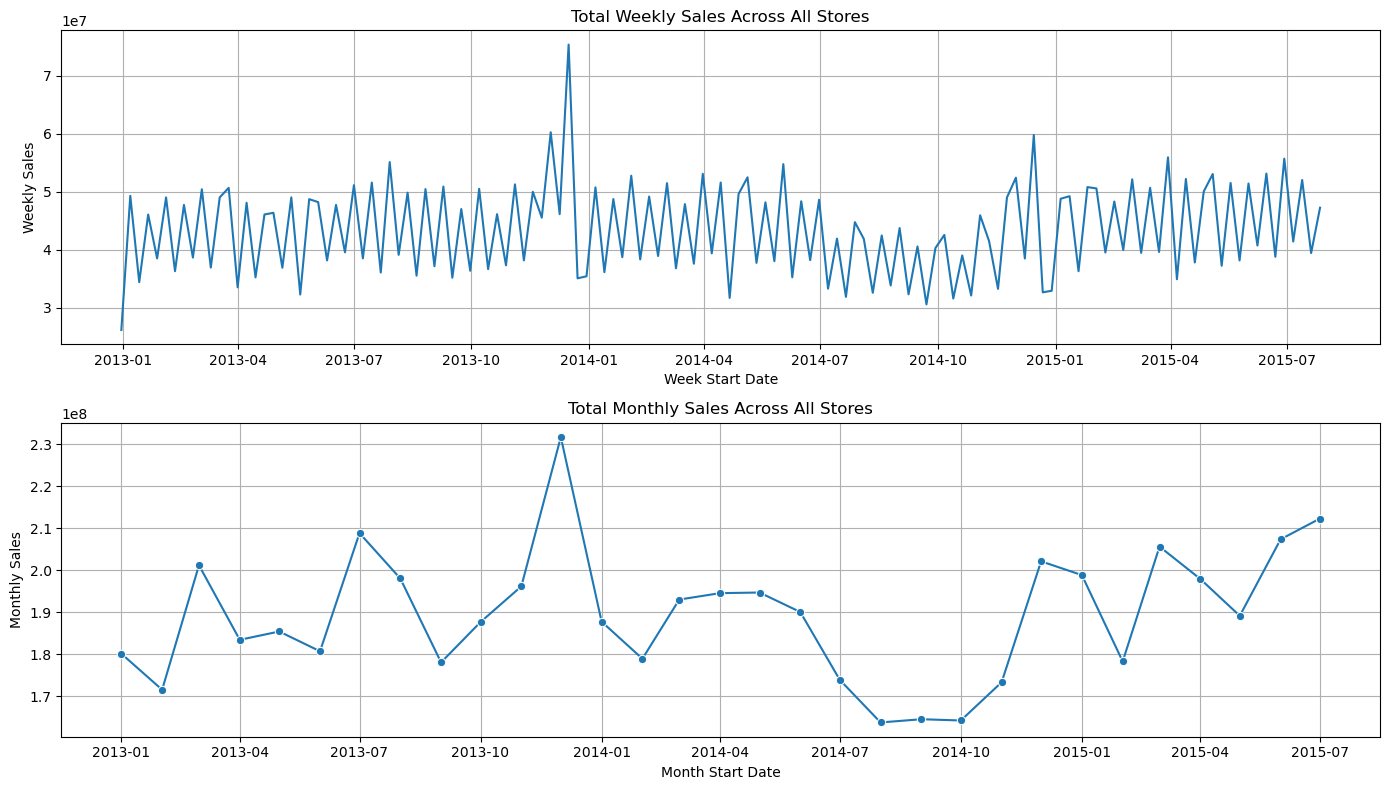

In [36]:
# Overall sales trend across all stores
weekly_trend = (
    weekly_df.groupby("WeekStartDate", as_index=False)["WeeklySales"].sum()
)

monthly_trend = (
    monthly_df.groupby("MonthStartDate", as_index=False)["MonthlySales"].sum()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

sns.lineplot(
    data=weekly_trend,
    x="WeekStartDate",
    y="WeeklySales",
    ax=ax1
)
ax1.set_title("Total Weekly Sales Across All Stores")
ax1.set_xlabel("Week Start Date")
ax1.set_ylabel("Weekly Sales")
ax1.grid(True)

sns.lineplot(
    data=monthly_trend,
    x="MonthStartDate",
    y="MonthlySales",
    marker="o",
    ax=ax2
)
ax2.set_title("Total Monthly Sales Across All Stores")
ax2.set_xlabel("Month Start Date")
ax2.set_ylabel("Monthly Sales")
ax2.grid(True)

plt.tight_layout()
plt.show()

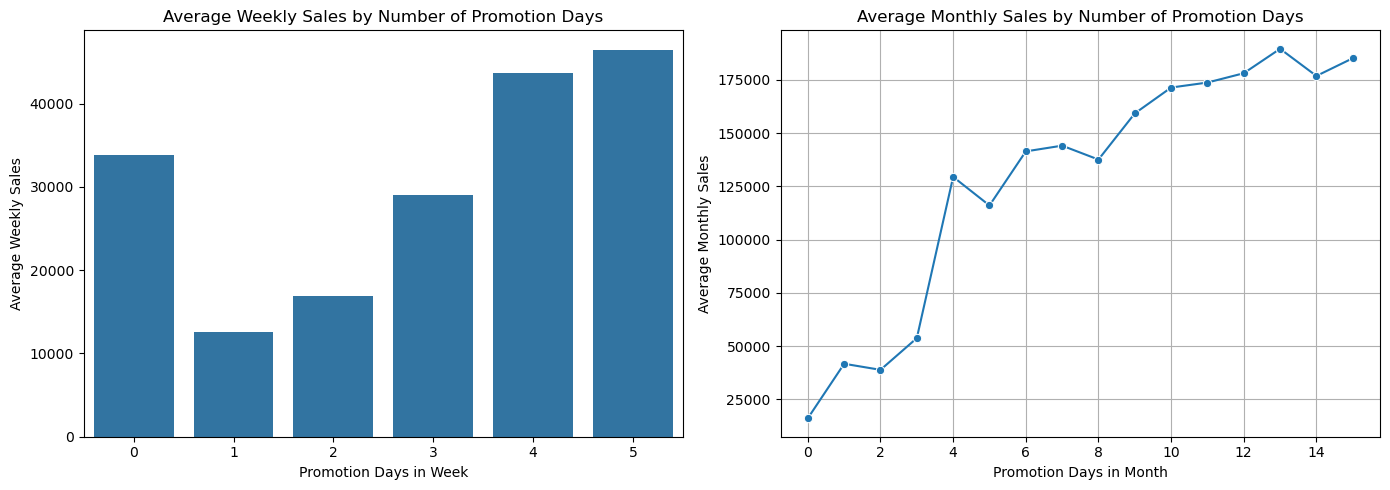

In [37]:
# Promotion effect on aggregated sales
promo_weekly = (
    weekly_df.groupby("PromoDays", as_index=False)["WeeklySales"].mean()
)

promo_monthly = (
    monthly_df.groupby("PromoDays", as_index=False)["MonthlySales"].mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=promo_weekly,
    x="PromoDays",
    y="WeeklySales",
    ax=axes[0]
)
axes[0].set_title("Average Weekly Sales by Number of Promotion Days")
axes[0].set_xlabel("Promotion Days in Week")
axes[0].set_ylabel("Average Weekly Sales")

sns.lineplot(
    data=promo_monthly,
    x="PromoDays",
    y="MonthlySales",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Average Monthly Sales by Number of Promotion Days")
axes[1].set_xlabel("Promotion Days in Month")
axes[1].set_ylabel("Average Monthly Sales")
axes[1].grid(True)

plt.tight_layout()
plt.show()

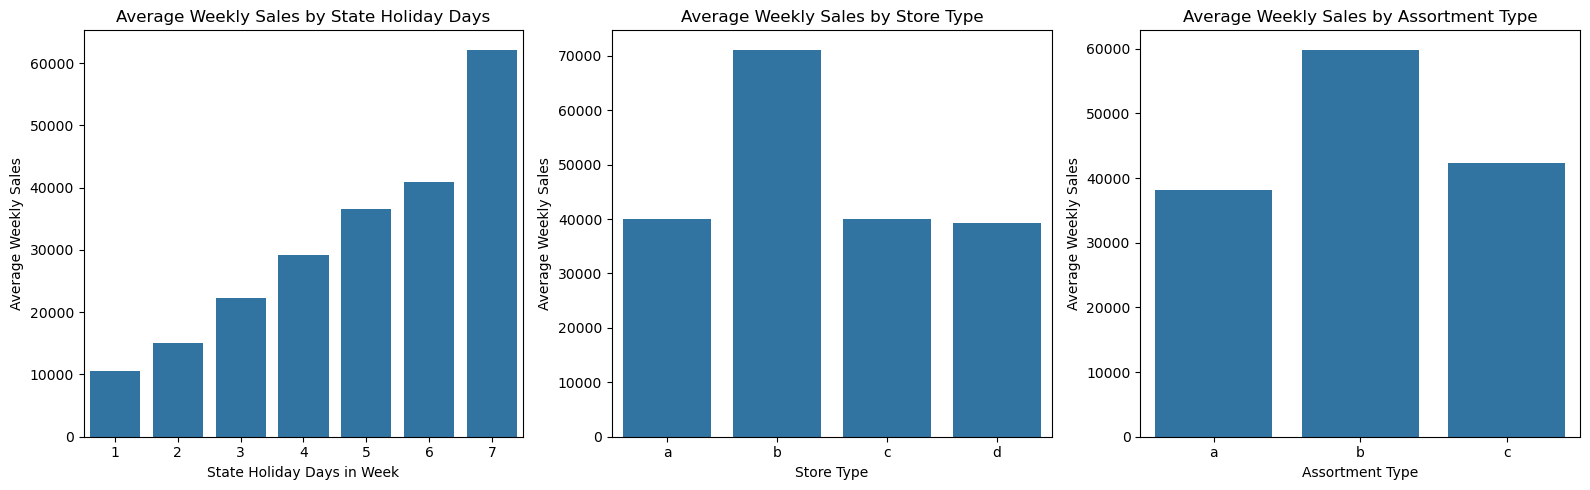

In [38]:
# Holiday and store-characteristic effects
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

holiday_weekly = (
    weekly_df
    .groupby("StateHolidayDays", as_index=False)["WeeklySales"]
    .mean()
)

sns.barplot(
    data=holiday_weekly,
    x="StateHolidayDays",
    y="WeeklySales",
    ax=axes[0]
)
axes[0].set_title("Average Weekly Sales by State Holiday Days")
axes[0].set_xlabel("State Holiday Days in Week")
axes[0].set_ylabel("Average Weekly Sales")

storetype_weekly = (
    weekly_df
    .groupby("StoreType", as_index=False)["WeeklySales"]
    .mean()
)

sns.barplot(
    data=storetype_weekly,
    x="StoreType",
    y="WeeklySales",
    ax=axes[1]
)
axes[1].set_title("Average Weekly Sales by Store Type")
axes[1].set_xlabel("Store Type")
axes[1].set_ylabel("Average Weekly Sales")

assortment_weekly = (
    weekly_df
    .groupby("Assortment", as_index=False)["WeeklySales"]
    .mean()
)

sns.barplot(
    data=assortment_weekly,
    x="Assortment",
    y="WeeklySales",
    ax=axes[2]
)
axes[2].set_title("Average Weekly Sales by Assortment Type")
axes[2].set_xlabel("Assortment Type")
axes[2].set_ylabel("Average Weekly Sales")

plt.tight_layout()
plt.show()

## 6. Lag, Rolling, EMA, and Promotion-History Feature Engineering

Historical sales features are created separately for each store to preserve store-level temporal behaviour and prevent cross-store contamination.

Lag, rolling, and exponential moving-average features use only information from previous periods. The current period's sales are excluded using `shift(1)` before rolling or EMA calculations.

**Features created:**

- Lag features representing sales from previous periods
- Rolling mean and standard deviation features
- Exponential moving averages (EMA)
- `periods_since_last_promo` — number of weekly or monthly periods since the previous active promotion

In [39]:
# Weekly lag, rolling, and EMA features
weekly_model_df = (
    weekly_df
    .sort_values(["Store", "WeekStartDate"])
    .copy()
)

# Lag features: calculated separately for each store
for lag in [1, 2, 4, 8, 52]:
    weekly_model_df[f"sales_lag_{lag}"] = (
        weekly_model_df
        .groupby("Store")["WeeklySales"]
        .shift(lag)
    )

# Rolling features:
# shift(1) ensures the current week's sales are not used
for window in [4, 8, 12]:
    weekly_model_df[f"rolling_mean_{window}"] = (
        weekly_model_df
        .groupby("Store")["WeeklySales"]
        .transform(
            lambda s: s.shift(1).rolling(window=window).mean()
        )
    )

    weekly_model_df[f"rolling_std_{window}"] = (
        weekly_model_df
        .groupby("Store")["WeeklySales"]
        .transform(
            lambda s: s.shift(1).rolling(window=window).std()
        )
    )

# Exponential moving averages:
# calculated independently within each store
for span in [4, 8]:
    weekly_model_df[f"EMA_{span}"] = (
        weekly_model_df
        .groupby("Store")["WeeklySales"]
        .transform(
            lambda s: s.shift(1).ewm(
                span=span,
                adjust=False
            ).mean()
        )
    )

print(
    "Weekly model dataset shape before dropna:",
    weekly_model_df.shape
)

Weekly model dataset shape before dropna: (145808, 38)


In [40]:
# Monthly lag, rolling, and EMA features
monthly_model_df = (
    monthly_df
    .sort_values(["Store", "MonthStartDate"])
    .copy()
)

# Lag features
for lag in [1, 2, 3, 12]:
    monthly_model_df[f"sales_lag_{lag}"] = (
        monthly_model_df
        .groupby("Store")["MonthlySales"]
        .shift(lag)
    )

# Rolling mean and standard deviation
for window in [3, 6]:
    monthly_model_df[f"rolling_mean_{window}"] = (
        monthly_model_df
        .groupby("Store")["MonthlySales"]
        .transform(
            lambda s: s.shift(1).rolling(window=window).mean()
        )
    )

    monthly_model_df[f"rolling_std_{window}"] = (
        monthly_model_df
        .groupby("Store")["MonthlySales"]
        .transform(
            lambda s: s.shift(1).rolling(window=window).std()
        )
    )

# Exponential moving averages
for span in [3, 6]:
    monthly_model_df[f"EMA_{span}"] = (
        monthly_model_df
        .groupby("Store")["MonthlySales"]
        .transform(
            lambda s: s.shift(1).ewm(
                span=span,
                adjust=False
            ).mean()
        )
    )

print(
    "Monthly model dataset shape before dropna:",
    monthly_model_df.shape
)

Monthly model dataset shape before dropna: (33465, 34)


In [41]:
# Periods since the last prior promotion
# Current-period PromoDays is excluded using shift(1).

def add_periods_since_promo(df, promo_col, date_col):
    df = df.sort_values(["Store", date_col]).copy()

    def _period_counter(series):
        # Only promotion information from previous periods
        previous_promo = series.shift(1).gt(0)

        # Each previous promotion starts a new counting group
        promo_group = previous_promo.cumsum()

        # 0 = immediately after a promotional period
        # 1 = one non-promotional period since then
        periods_since = previous_promo.groupby(promo_group).cumcount().astype(float)

        # -1 means no earlier promotion has been observed for this store
        periods_since[promo_group == 0] = -1

        return periods_since

    df["periods_since_last_promo"] = (
        df.groupby("Store")[promo_col]
          .transform(_period_counter)
    )

    return df


weekly_model_df = add_periods_since_promo(
    weekly_model_df,
    "PromoDays",
    "WeekStartDate"
)

monthly_model_df = add_periods_since_promo(
    monthly_model_df,
    "PromoDays",
    "MonthStartDate"
)

print("Weekly promotion-history sample:")
print(
    weekly_model_df[
        ["Store", "WeekStartDate", "PromoDays", "periods_since_last_promo"]
    ].head(15)
)

Weekly promotion-history sample:
    Store WeekStartDate  PromoDays  periods_since_last_promo
0       1    2012-12-31          0                      -1.0
1       1    2013-01-07          5                      -1.0
2       1    2013-01-14          0                       0.0
3       1    2013-01-21          5                       1.0
4       1    2013-01-28          0                       0.0
5       1    2013-02-04          5                       1.0
6       1    2013-02-11          0                       0.0
7       1    2013-02-18          5                       1.0
8       1    2013-02-25          0                       0.0
9       1    2013-03-04          5                       1.0
10      1    2013-03-11          0                       0.0
11      1    2013-03-18          5                       1.0
12      1    2013-03-25          4                       0.0
13      1    2013-04-01          0                       0.0
14      1    2013-04-08          5                  

In [42]:
# Check NaN created by lag/rolling features
print("Weekly missing values after feature engineering:")
w_missing = weekly_model_df.isnull().sum()
print(w_missing[w_missing > 0])

print("\nMonthly missing values after feature engineering:")
m_missing = monthly_model_df.isnull().sum()
print(m_missing[m_missing > 0])

Weekly missing values after feature engineering:
sales_lag_1         1115
sales_lag_2         2230
sales_lag_4         4460
sales_lag_8         8920
sales_lag_52       57980
rolling_mean_4      4460
rolling_std_4       4460
rolling_mean_8      8920
rolling_std_8       8920
rolling_mean_12    13380
rolling_std_12     13380
EMA_4               1115
EMA_8               1115
dtype: int64

Monthly missing values after feature engineering:
sales_lag_1        1115
sales_lag_2        2230
sales_lag_3        3345
sales_lag_12      13380
rolling_mean_3     3345
rolling_std_3      3345
rolling_mean_6     6690
rolling_std_6      6690
EMA_3              1115
EMA_6              1115
dtype: int64


In [43]:
# Remove warm-up rows without sufficient historical feature data
# Missing values occur at the beginning of each store's history because
# lag, rolling, and EMA features require observations from previous periods.

weekly_model_df = (
    weekly_model_df
    .dropna()
    .reset_index(drop=True)
)

monthly_model_df = (
    monthly_model_df
    .dropna()
    .reset_index(drop=True)
)

print(
    "Weekly after dropna:",
    weekly_model_df.shape,
    "| Missing:",
    weekly_model_df.isnull().sum().sum()
)

print(
    "Monthly after dropna:",
    monthly_model_df.shape,
    "| Missing:",
    monthly_model_df.isnull().sum().sum()
)

Weekly after dropna: (87828, 39) | Missing: 0
Monthly after dropna: (20085, 35) | Missing: 0


## 7. Modelling Dataset Preparation and Chronological Split

Categorical variables are encoded, predictor features and target variables are defined, and the weekly and monthly datasets are divided using chronological boundaries.

A chronological split is used instead of random sampling so that later observations are not used to predict earlier periods.

| Split | Date range | Purpose |
|---|---|---|
| Train | Up to 2014-12-31 | Model training |
| Validation | 2015-01-01 to 2015-04-30 | Model selection and parameter tuning |
| Test | 2015-05-01 onwards | Final model evaluation and reported performance |

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error (MAPE)."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return (
        np.mean(
            np.abs(
                (y_true - y_pred) /
                np.maximum(np.abs(y_true), 1e-8)
            )
        ) * 100
    )


def rmspe(y_true, y_pred):
    """Calculate Root Mean Squared Percentage Error (RMSPE)."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return (
        np.sqrt(
            np.mean(
                (
                    (y_true - y_pred) /
                    np.maximum(np.abs(y_true), 1e-8)
                ) ** 2
            )
        ) * 100
    )


def evaluate_model(y_true, y_pred):
    """Return MAE, RMSE, MAPE, and RMSPE."""
    return {
        "MAE": round(
            mean_absolute_error(y_true, y_pred), 3
        ),
        "RMSE": round(
            np.sqrt(mean_squared_error(y_true, y_pred)), 3
        ),
        "MAPE": round(
            mape(y_true, y_pred), 3
        ),
        "RMSPE": round(
            rmspe(y_true, y_pred), 3
        ),
    }


print(
    "Evaluation functions defined: MAE, RMSE, MAPE, RMSPE"
)

Evaluation functions defined: MAE, RMSE, MAPE, RMSPE


In [45]:
# One-hot encode categorical store attributes
CAT_COLS = [
    "StoreType",
    "Assortment",
    "PromoInterval"
]

weekly_encoded = pd.get_dummies(
    weekly_model_df,
    columns=CAT_COLS,
    drop_first=False,
    dtype=int
)

monthly_encoded = pd.get_dummies(
    monthly_model_df,
    columns=CAT_COLS,
    drop_first=False,
    dtype=int
)

print("Weekly encoded:", weekly_encoded.shape)
print("Monthly encoded:", monthly_encoded.shape)

Weekly encoded: (87828, 47)
Monthly encoded: (20085, 43)


In [46]:
# Define target and predictor feature columns

WEEKLY_TARGET = "WeeklySales"
MONTHLY_TARGET = "MonthlySales"

# Columns excluded from model inputs
weekly_exclude = [
    WEEKLY_TARGET,
    "WeekStartDate",
    "YearWeek",
    "YearMonth"
]

monthly_exclude = [
    MONTHLY_TARGET,
    "MonthStartDate",
    "YearMonth"
]

weekly_features = [
    col for col in weekly_encoded.columns
    if col not in weekly_exclude
]

monthly_features = [
    col for col in monthly_encoded.columns
    if col not in monthly_exclude
]

print(f"Weekly features: {len(weekly_features)}")
print(f"Monthly features: {len(monthly_features)}")

Weekly features: 45
Monthly features: 41


In [47]:
# Chronological train / validation / test split
def chronological_split(
    df,
    date_col,
    train_end="2014-12-31",
    val_end="2015-04-30"
):
    train_end = pd.Timestamp(train_end)
    val_end = pd.Timestamp(val_end)

    train = df[df[date_col] <= train_end].copy()

    val = df[
        (df[date_col] > train_end) &
        (df[date_col] <= val_end)
    ].copy()

    test = df[df[date_col] > val_end].copy()

    # Validate that every observation belongs to exactly one split
    assert len(train) + len(val) + len(test) == len(df)

    # Validate chronological ordering
    assert train[date_col].max() < val[date_col].min()
    assert val[date_col].max() < test[date_col].min()

    return train, val, test


weekly_train_df, weekly_val_df, weekly_test_df = chronological_split(
    weekly_encoded,
    "WeekStartDate"
)

monthly_train_df, monthly_val_df, monthly_test_df = chronological_split(
    monthly_encoded,
    "MonthStartDate"
)


for label, frame, date_col in [
    ("Weekly train", weekly_train_df, "WeekStartDate"),
    ("Weekly val", weekly_val_df, "WeekStartDate"),
    ("Weekly test", weekly_test_df, "WeekStartDate"),
    ("Monthly train", monthly_train_df, "MonthStartDate"),
    ("Monthly val", monthly_val_df, "MonthStartDate"),
    ("Monthly test", monthly_test_df, "MonthStartDate"),
]:
    print(
        f"{label:13}: {frame.shape} | "
        f"{frame[date_col].min().date()} -> "
        f"{frame[date_col].max().date()}"
    )

Weekly train : (54396, 47) | 2013-12-30 -> 2014-12-29
Weekly val   : (18945, 47) | 2015-01-05 -> 2015-04-27
Weekly test  : (14487, 47) | 2015-05-04 -> 2015-07-27
Monthly train: (12280, 43) | 2014-01-01 -> 2014-12-01
Monthly val  : (4460, 43) | 2015-01-01 -> 2015-04-01
Monthly test : (3345, 43) | 2015-05-01 -> 2015-07-01


In [48]:
# Create feature matrices (X) and target vectors (y)

X_weekly_train = weekly_train_df[weekly_features]
y_weekly_train = weekly_train_df[WEEKLY_TARGET]

X_weekly_val = weekly_val_df[weekly_features]
y_weekly_val = weekly_val_df[WEEKLY_TARGET]

X_weekly_test = weekly_test_df[weekly_features]
y_weekly_test = weekly_test_df[WEEKLY_TARGET]


X_monthly_train = monthly_train_df[monthly_features]
y_monthly_train = monthly_train_df[MONTHLY_TARGET]

X_monthly_val = monthly_val_df[monthly_features]
y_monthly_val = monthly_val_df[MONTHLY_TARGET]

X_monthly_test = monthly_test_df[monthly_features]
y_monthly_test = monthly_test_df[MONTHLY_TARGET]


print("Weekly X shapes:",
      X_weekly_train.shape,
      X_weekly_val.shape,
      X_weekly_test.shape)

print("Monthly X shapes:",
      X_monthly_train.shape,
      X_monthly_val.shape,
      X_monthly_test.shape)

Weekly X shapes: (54396, 45) (18945, 45) (14487, 45)
Monthly X shapes: (12280, 41) (4460, 41) (3345, 41)


## 8. Moving Average Baseline Model

A simple moving-average forecast is used as a baseline for comparison with the machine-learning models.

The baseline uses previously calculated leakage-safe rolling-mean features, which are based only on sales from earlier periods. Model performance is compared against this baseline using MAE, RMSE, MAPE, and RMSPE.

In [49]:
# Weekly moving-average baseline evaluated on validation data

weekly_ma_features = {
    "Moving Average 4 Weeks": "rolling_mean_4",
    "Moving Average 8 Weeks": "rolling_mean_8",
    "Moving Average 12 Weeks": "rolling_mean_12",
}

weekly_ma_val_results = []

for model_name, feature in weekly_ma_features.items():
    metrics = evaluate_model(
        y_weekly_val,
        weekly_val_df[feature]
    )

    weekly_ma_val_results.append({
        "Model": model_name,
        "Forecast Type": "Weekly",
        **metrics
    })

weekly_ma_val_results_df = pd.DataFrame(
    weekly_ma_val_results
)

display(weekly_ma_val_results_df)

,Model,Forecast Type,MAE,RMSE,MAPE,RMSPE
0,Moving Average 4 Weeks,Weekly,6279.100,7604.046,16.236,19.378
1,Moving Average 8 Weeks,Weekly,6285.035,7763.277,16.491,20.405
2,Moving Average 12 Weeks,Weekly,6136.713,7604.466,16.190,20.114


In [50]:
# Select the best weekly moving-average baseline using validation MAE

best_weekly_ma_row = weekly_ma_val_results_df.loc[
    weekly_ma_val_results_df["MAE"].idxmin()
]

best_weekly_ma_name = best_weekly_ma_row["Model"]

best_weekly_ma_feature = weekly_ma_features[
    best_weekly_ma_name
]

print("Selected weekly baseline:", best_weekly_ma_name)
print("Validation MAE:", best_weekly_ma_row["MAE"])

Selected weekly baseline: Moving Average 12 Weeks
Validation MAE: 6136.713


In [51]:
# Final test evaluation of selected weekly baseline

weekly_ma_test_metrics = evaluate_model(
    y_weekly_test,
    weekly_test_df[best_weekly_ma_feature]
)

weekly_ma_test_result = pd.DataFrame([
    {
        "Model": best_weekly_ma_name,
        "Forecast Type": "Weekly",
        **weekly_ma_test_metrics
    }
])

display(weekly_ma_test_result)

,Model,Forecast Type,MAE,RMSE,MAPE,RMSPE
0,Moving Average 12 Weeks,Weekly,6485.035,7511.622,16.499,19.266


In [53]:
# Monthly moving-average baseline evaluated on validation data

monthly_ma_features = {
    "Moving Average 3 Months": "rolling_mean_3",
    "Moving Average 6 Months": "rolling_mean_6",
}

monthly_ma_val_results = []

for model_name, feature in monthly_ma_features.items():
    metrics = evaluate_model(
        y_monthly_val,
        monthly_val_df[feature]
    )

    monthly_ma_val_results.append({
        "Model": model_name,
        "Forecast Type": "Monthly",
        **metrics
    })

monthly_ma_val_results_df = pd.DataFrame(
    monthly_ma_val_results
)

display(monthly_ma_val_results_df)

,Model,Forecast Type,MAE,RMSE,MAPE,RMSPE
0,Moving Average 3 Months,Monthly,13905.978,19941.819,8.357,11.969
1,Moving Average 6 Months,Monthly,11366.489,16212.282,6.848,10.169


In [54]:
# Select the best monthly moving-average baseline using validation MAE

best_monthly_ma_row = monthly_ma_val_results_df.loc[
    monthly_ma_val_results_df["MAE"].idxmin()
]

best_monthly_ma_name = best_monthly_ma_row["Model"]

best_monthly_ma_feature = monthly_ma_features[
    best_monthly_ma_name
]

print("Selected monthly baseline:", best_monthly_ma_name)
print("Validation MAE:", best_monthly_ma_row["MAE"])

Selected monthly baseline: Moving Average 6 Months
Validation MAE: 11366.489


In [55]:
# Final test evaluation of selected monthly baseline

monthly_ma_test_metrics = evaluate_model(
    y_monthly_test,
    monthly_test_df[best_monthly_ma_feature]
)

monthly_ma_test_result = pd.DataFrame([
    {
        "Model": best_monthly_ma_name,
        "Forecast Type": "Monthly",
        **monthly_ma_test_metrics
    }
])

display(monthly_ma_test_result)

,Model,Forecast Type,MAE,RMSE,MAPE,RMSPE
0,Moving Average 6 Months,Monthly,12816.886,17083.914,7.109,9.717


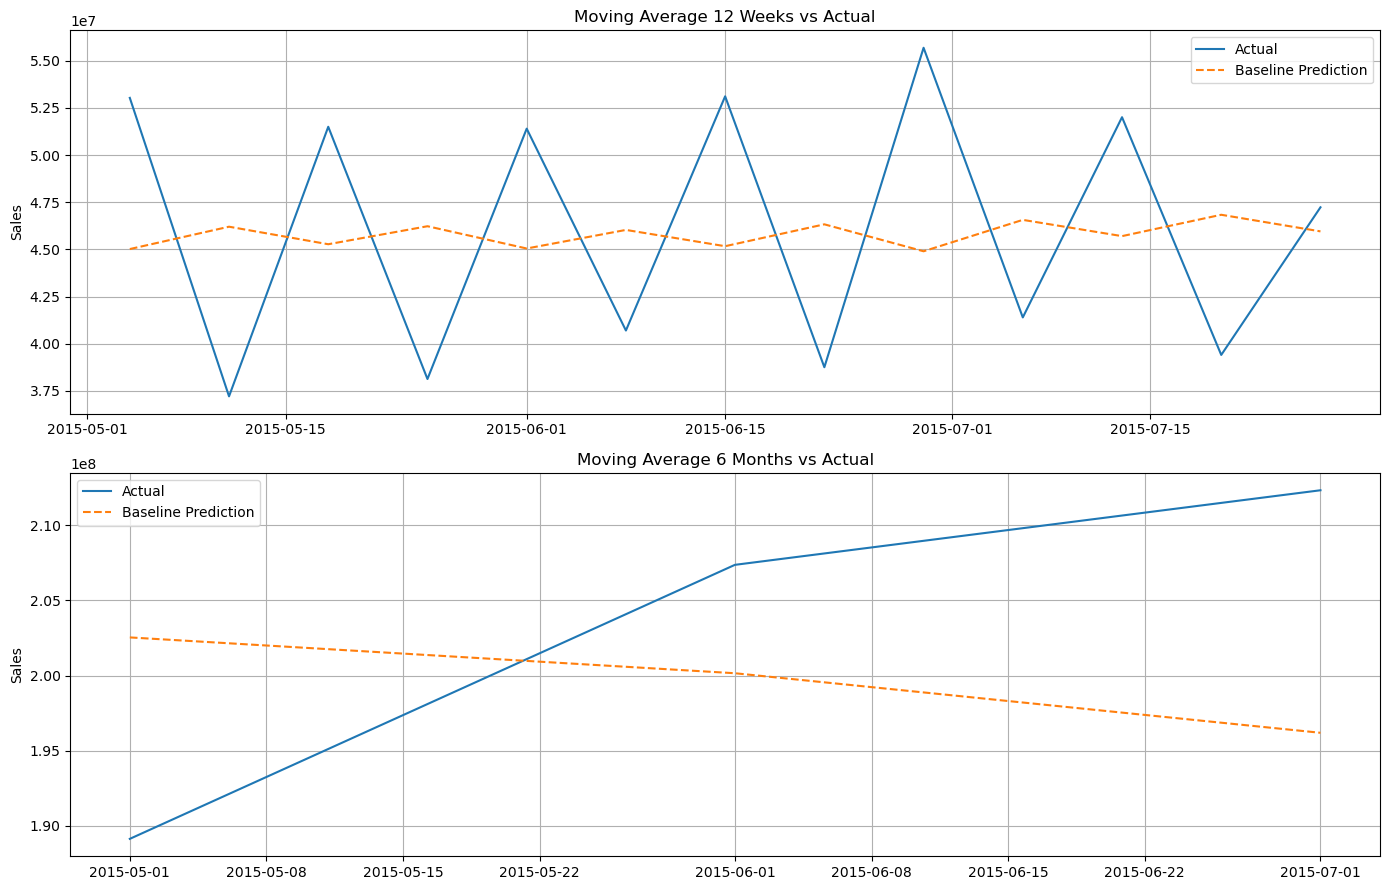

In [56]:
# Actual vs selected moving-average baseline predictions

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for ax, test_df, feature, date_col, target_col, title in [
    (
        axes[0],
        weekly_test_df,
        best_weekly_ma_feature,
        "WeekStartDate",
        WEEKLY_TARGET,
        f"{best_weekly_ma_name} vs Actual"
    ),
    (
        axes[1],
        monthly_test_df,
        best_monthly_ma_feature,
        "MonthStartDate",
        MONTHLY_TARGET,
        f"{best_monthly_ma_name} vs Actual"
    ),
]:
    aggregated = (
        test_df
        .groupby(date_col)[[target_col, feature]]
        .sum()
    )

    ax.plot(
        aggregated.index,
        aggregated[target_col],
        label="Actual"
    )

    ax.plot(
        aggregated.index,
        aggregated[feature],
        label="Baseline Prediction",
        linestyle="--"
    )

    ax.set_title(title)
    ax.set_ylabel("Sales")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [57]:
# Final selected moving-average baseline results

baseline_results_df = pd.concat(
    [
        weekly_ma_test_result,
        monthly_ma_test_result
    ],
    ignore_index=True
)

display(baseline_results_df)

,Model,Forecast Type,MAE,RMSE,MAPE,RMSPE
0,Moving Average 12 Weeks,Weekly,6485.035,7511.622,16.499,19.266
1,Moving Average 6 Months,Monthly,12816.886,17083.914,7.109,9.717


## 9. Random Forest Regressor

Random Forest regression is trained separately for the weekly and monthly forecasting tasks.

Model selection and parameter decisions are based on validation-set performance. The held-out test set is reserved for final evaluation only, reducing the risk of overfitting model choices to the test period.

In [64]:
from sklearn.ensemble import RandomForestRegressor

# Candidate Random Forest configurations.
# Model selection is based only on validation MAE.

rf_weekly_candidates = [
    {
        "Name": "RF_depth10_leaf10",
        "max_depth": 10,
        "min_samples_leaf": 10,
        "max_features": 0.8
    },
    {
        "Name": "RF_depth12_leaf10",
        "max_depth": 12,
        "min_samples_leaf": 10,
        "max_features": 0.8
    },
    {
        "Name": "RF_depth12_leaf20",
        "max_depth": 12,
        "min_samples_leaf": 20,
        "max_features": 0.8
    },
    {
        "Name": "RF_depth15_leaf5",
        "max_depth": 15,
        "min_samples_leaf": 5,
        "max_features": 1.0
    }
]

rf_weekly_results = []
rf_weekly_candidate_models = {}

for config in rf_weekly_candidates:

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        max_features=config["max_features"],
        n_jobs=-1,
        random_state=42
    )

    # Train using training data only
    model.fit(
        X_weekly_train,
        y_weekly_train
    )

    # Training and validation predictions
    train_pred = model.predict(X_weekly_train)
    val_pred = model.predict(X_weekly_val)

    train_metrics = evaluate_model(
        y_weekly_train,
        train_pred
    )

    val_metrics = evaluate_model(
        y_weekly_val,
        val_pred
    )

    rf_weekly_results.append({
        "Model": config["Name"],
        "Train_MAE": train_metrics["MAE"],
        "Validation_MAE": val_metrics["MAE"],
        "Validation_RMSE": val_metrics["RMSE"],
        "Validation_MAPE": val_metrics["MAPE"],
        "Validation_RMSPE": val_metrics["RMSPE"]
    })

    rf_weekly_candidate_models[
        config["Name"]
    ] = model


rf_weekly_tuning_df = (
    pd.DataFrame(rf_weekly_results)
    .sort_values("Validation_MAE")
    .reset_index(drop=True)
)

display(rf_weekly_tuning_df)

,Model,Train_MAE,Validation_MAE,Validation_RMSE,Validation_MAPE,Validation_RMSPE
0,RF_depth15_leaf5,1285.554,3198.765,4524.059,7.810,10.512
1,RF_depth12_leaf20,1818.922,3205.602,4517.483,7.869,10.596
2,RF_depth10_leaf10,1949.686,3241.907,4539.174,7.971,10.676
3,RF_depth12_leaf10,1698.214,3246.500,4568.761,7.942,10.662


In [65]:
from sklearn.ensemble import RandomForestRegressor

# Candidate Random Forest configurations.
# Model selection is based only on validation MAE.

rf_weekly_candidates = [
    {
        "Name": "RF_depth10_leaf10",
        "max_depth": 10,
        "min_samples_leaf": 10,
        "max_features": 0.8
    },
    {
        "Name": "RF_depth12_leaf10",
        "max_depth": 12,
        "min_samples_leaf": 10,
        "max_features": 0.8
    },
    {
        "Name": "RF_depth12_leaf20",
        "max_depth": 12,
        "min_samples_leaf": 20,
        "max_features": 0.8
    },
    {
        "Name": "RF_depth15_leaf5",
        "max_depth": 15,
        "min_samples_leaf": 5,
        "max_features": 1.0
    }
]

rf_weekly_results = []
rf_weekly_candidate_models = {}

for config in rf_weekly_candidates:

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        max_features=config["max_features"],
        n_jobs=-1,
        random_state=42
    )

    # Train using training data only
    model.fit(
        X_weekly_train,
        y_weekly_train
    )

    # Training and validation predictions
    train_pred = model.predict(X_weekly_train)
    val_pred = model.predict(X_weekly_val)

    train_metrics = evaluate_model(
        y_weekly_train,
        train_pred
    )

    val_metrics = evaluate_model(
        y_weekly_val,
        val_pred
    )

    rf_weekly_results.append({
        "Model": config["Name"],
        "Train_MAE": train_metrics["MAE"],
        "Validation_MAE": val_metrics["MAE"],
        "Validation_RMSE": val_metrics["RMSE"],
        "Validation_MAPE": val_metrics["MAPE"],
        "Validation_RMSPE": val_metrics["RMSPE"]
    })

    rf_weekly_candidate_models[
        config["Name"]
    ] = model


rf_weekly_tuning_df = (
    pd.DataFrame(rf_weekly_results)
    .sort_values("Validation_MAE")
    .reset_index(drop=True)
)

display(rf_weekly_tuning_df)

,Model,Train_MAE,Validation_MAE,Validation_RMSE,Validation_MAPE,Validation_RMSPE
0,RF_depth15_leaf5,1285.554,3198.765,4524.059,7.810,10.512
1,RF_depth12_leaf20,1818.922,3205.602,4517.483,7.869,10.596
2,RF_depth10_leaf10,1949.686,3241.907,4539.174,7.971,10.676
3,RF_depth12_leaf10,1698.214,3246.500,4568.761,7.942,10.662


In [66]:
# Final evaluation on the held-out test set

rf_weekly_test_pred = (
    rf_weekly_model.predict(
        X_weekly_test
    )
)

rf_weekly_test_metrics = evaluate_model(
    y_weekly_test,
    rf_weekly_test_pred
)

rf_weekly_test_result = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Forecast Type": "Weekly",
        "Dataset": "Test",
        **rf_weekly_test_metrics
    }
])

display(rf_weekly_test_result)

,Model,Forecast Type,Dataset,MAE,RMSE,MAPE,RMSPE
0,Random Forest,Weekly,Test,2760.274,4164.14,6.674,9.627


In [67]:
# Monthly Random Forest model selection using validation data

rf_monthly_candidates = [
    {
        "Name": "RF_depth10_leaf10",
        "max_depth": 10,
        "min_samples_leaf": 10,
        "max_features": 0.8
    },
    {
        "Name": "RF_depth12_leaf10",
        "max_depth": 12,
        "min_samples_leaf": 10,
        "max_features": 0.8
    },
    {
        "Name": "RF_depth12_leaf20",
        "max_depth": 12,
        "min_samples_leaf": 20,
        "max_features": 0.8
    },
    {
        "Name": "RF_depth15_leaf5",
        "max_depth": 15,
        "min_samples_leaf": 5,
        "max_features": 1.0
    }
]

rf_monthly_results = []
rf_monthly_candidate_models = {}

for config in rf_monthly_candidates:

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        max_features=config["max_features"],
        n_jobs=-1,
        random_state=42
    )

    # Train using training data only
    model.fit(
        X_monthly_train,
        y_monthly_train
    )

    # Train and validation predictions
    train_pred = model.predict(X_monthly_train)
    val_pred = model.predict(X_monthly_val)

    train_metrics = evaluate_model(
        y_monthly_train,
        train_pred
    )

    val_metrics = evaluate_model(
        y_monthly_val,
        val_pred
    )

    rf_monthly_results.append({
        "Model": config["Name"],
        "Train_MAE": train_metrics["MAE"],
        "Validation_MAE": val_metrics["MAE"],
        "Validation_RMSE": val_metrics["RMSE"],
        "Validation_MAPE": val_metrics["MAPE"],
        "Validation_RMSPE": val_metrics["RMSPE"]
    })

    rf_monthly_candidate_models[
        config["Name"]
    ] = model


rf_monthly_tuning_df = (
    pd.DataFrame(rf_monthly_results)
    .sort_values("Validation_MAE")
    .reset_index(drop=True)
)

display(rf_monthly_tuning_df)

,Model,Train_MAE,Validation_MAE,Validation_RMSE,Validation_MAPE,Validation_RMSPE
0,RF_depth15_leaf5,3628.603,10106.561,13368.128,6.116,8.257
1,RF_depth10_leaf10,4990.069,10448.162,13830.253,6.368,8.650
2,RF_depth12_leaf10,4684.774,10495.702,13867.576,6.402,8.685
3,RF_depth12_leaf20,5405.357,10569.113,14102.434,6.441,8.817


In [68]:
# Select monthly Random Forest using validation MAE

best_rf_monthly_name = (
    rf_monthly_tuning_df.iloc[0]["Model"]
)

rf_monthly_model = (
    rf_monthly_candidate_models[
        best_rf_monthly_name
    ]
)

best_rf_monthly_validation_mae = (
    rf_monthly_tuning_df.iloc[0]["Validation_MAE"]
)

print(
    "Selected monthly Random Forest:",
    best_rf_monthly_name
)

print(
    "Validation MAE:",
    round(best_rf_monthly_validation_mae, 3)
)

Selected monthly Random Forest: RF_depth15_leaf5
Validation MAE: 10106.561


In [69]:
# Final evaluation of selected monthly Random Forest

rf_monthly_test_pred = rf_monthly_model.predict(
    X_monthly_test
)

rf_monthly_test_metrics = evaluate_model(
    y_monthly_test,
    rf_monthly_test_pred
)

rf_monthly_test_result = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Forecast Type": "Monthly",
        "Dataset": "Test",
        **rf_monthly_test_metrics
    }
])

display(rf_monthly_test_result)

,Model,Forecast Type,Dataset,MAE,RMSE,MAPE,RMSPE
0,Random Forest,Monthly,Test,9234.614,12643.827,5.224,7.987


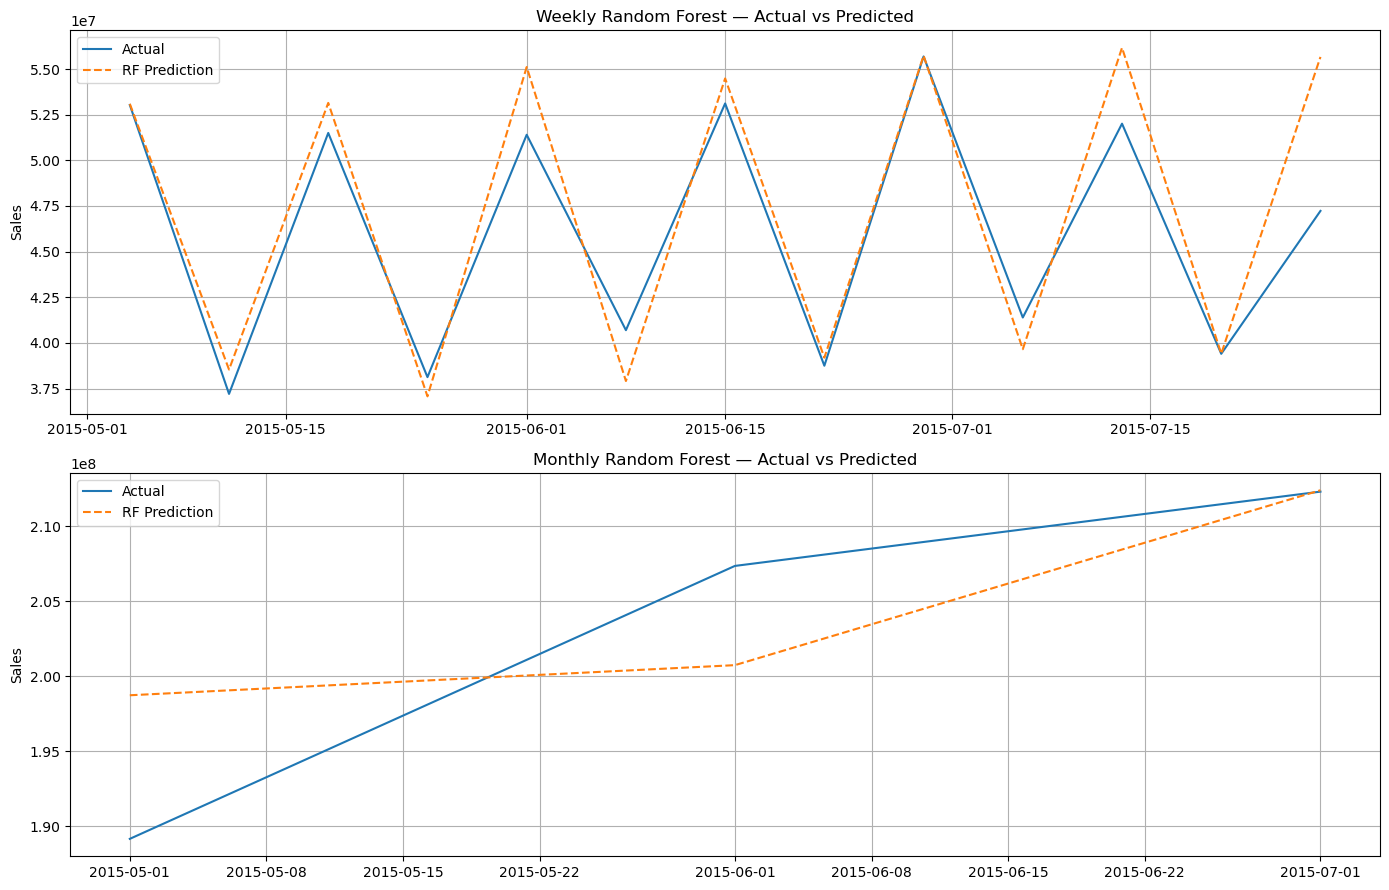

In [70]:
# Actual vs predicted sales for selected Random Forest models

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

plot_configs = [
    (
        axes[0],
        weekly_test_df,
        rf_weekly_test_pred,
        "WeekStartDate",
        WEEKLY_TARGET,
        "Weekly Random Forest"
    ),
    (
        axes[1],
        monthly_test_df,
        rf_monthly_test_pred,
        "MonthStartDate",
        MONTHLY_TARGET,
        "Monthly Random Forest"
    )
]

for ax, test_df, pred, date_col, sales_col, title in plot_configs:

    aggregated = (
        test_df
        .assign(Prediction=pred)
        .groupby(date_col)[[sales_col, "Prediction"]]
        .sum()
    )

    ax.plot(
        aggregated.index,
        aggregated[sales_col],
        label="Actual"
    )

    ax.plot(
        aggregated.index,
        aggregated["Prediction"],
        label="RF Prediction",
        linestyle="--"
    )

    ax.set_title(f"{title} — Actual vs Predicted")
    ax.set_ylabel("Sales")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

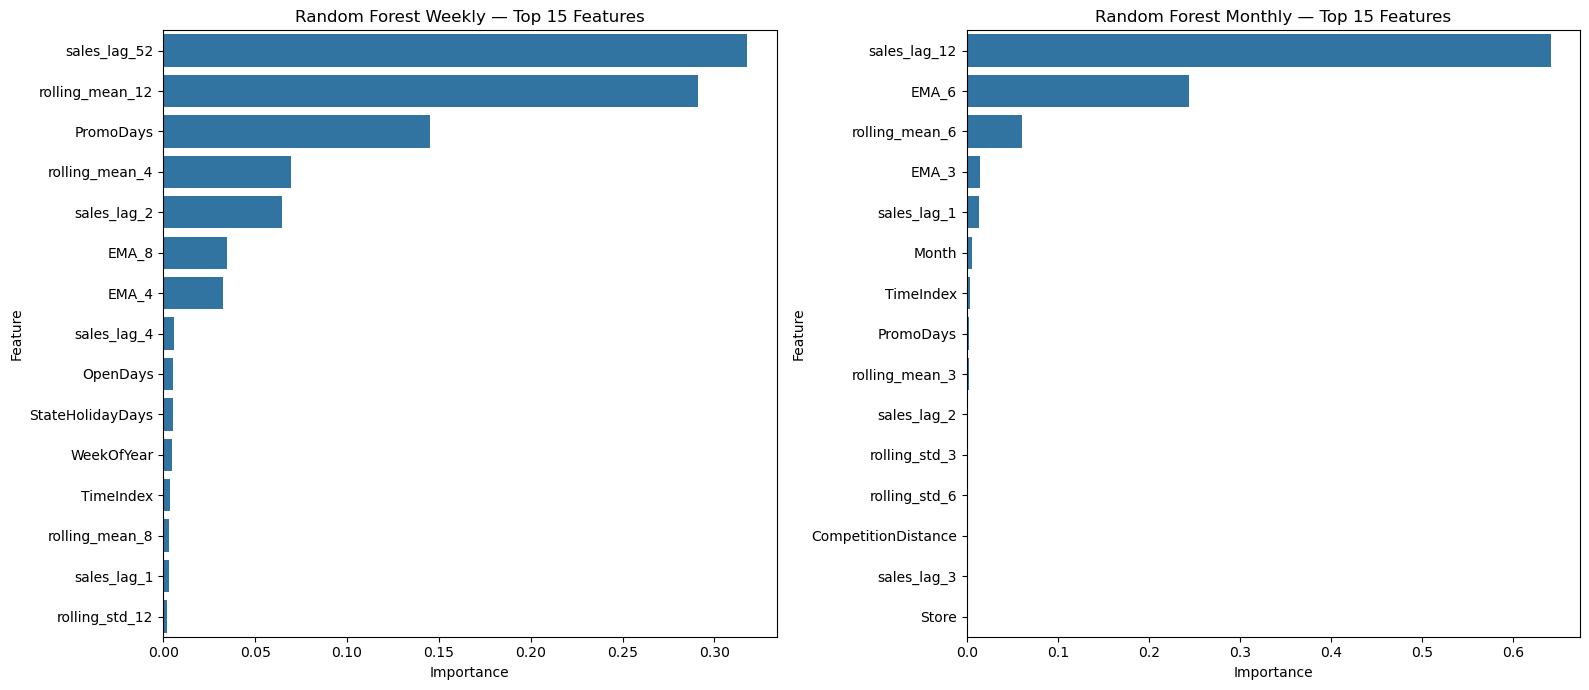

In [71]:
# Random Forest feature importance

rf_weekly_importance = (
    pd.DataFrame({
        "Feature": weekly_features,
        "Importance": rf_weekly_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

rf_monthly_importance = (
    pd.DataFrame({
        "Feature": monthly_features,
        "Importance": rf_monthly_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=rf_weekly_importance.head(15),
    x="Importance",
    y="Feature",
    ax=axes[0]
)
axes[0].set_title("Random Forest Weekly — Top 15 Features")

sns.barplot(
    data=rf_monthly_importance.head(15),
    x="Importance",
    y="Feature",
    ax=axes[1]
)
axes[1].set_title("Random Forest Monthly — Top 15 Features")

plt.tight_layout()
plt.show()

In [72]:
# Combine final Random Forest test results

rf_results_df = pd.concat(
    [
        rf_weekly_test_result,
        rf_monthly_test_result
    ],
    ignore_index=True
)

display(rf_results_df)

,Model,Forecast Type,Dataset,MAE,RMSE,MAPE,RMSPE
0,Random Forest,Weekly,Test,2760.274,4164.140,6.674,9.627
1,Random Forest,Monthly,Test,9234.614,12643.827,5.224,7.987


## 10. XGBoost Regressor

XGBoost regression models are trained separately for weekly and monthly sales forecasting.

Candidate configurations are compared using validation-set performance only. The held-out test set is reserved for final evaluation after model selection to reduce the risk of overfitting model choices to the test period.

In [77]:
from xgboost import XGBRegressor

# Weekly XGBoost candidate configurations.
# Model selection is based only on validation MAE.

xgb_weekly_candidates = [
    {
        "Name": "XGB_depth4_child5",
        "max_depth": 4,
        "min_child_weight": 5
    },
    {
        "Name": "XGB_depth6_child5",
        "max_depth": 6,
        "min_child_weight": 5
    },
    {
        "Name": "XGB_depth4_child10",
        "max_depth": 4,
        "min_child_weight": 10
    },
    {
        "Name": "XGB_depth6_child10",
        "max_depth": 6,
        "min_child_weight": 10
    }
]

In [78]:
# Weekly XGBoost validation-based model selection

xgb_weekly_tuning_results = []
xgb_weekly_candidate_models = {}

for config in xgb_weekly_candidates:

    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=config["max_depth"],
        min_child_weight=config["min_child_weight"],
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        eval_metric="mae",
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )

    # Train only on training data.
    # Validation data is used for early stopping.
    model.fit(
        X_weekly_train,
        y_weekly_train,
        eval_set=[(X_weekly_val, y_weekly_val)],
        verbose=False
    )

    # Train and validation predictions
    train_pred = model.predict(X_weekly_train)
    val_pred = model.predict(X_weekly_val)

    train_metrics = evaluate_model(
        y_weekly_train,
        train_pred
    )

    val_metrics = evaluate_model(
        y_weekly_val,
        val_pred
    )

    xgb_weekly_tuning_results.append({
        "Model": config["Name"],
        "Best_Iteration": model.best_iteration,
        "Train_MAE": train_metrics["MAE"],
        "Validation_MAE": val_metrics["MAE"],
        "Validation_RMSE": val_metrics["RMSE"],
        "Validation_MAPE": val_metrics["MAPE"],
        "Validation_RMSPE": val_metrics["RMSPE"]
    })

    xgb_weekly_candidate_models[
        config["Name"]
    ] = model


xgb_weekly_tuning_df = (
    pd.DataFrame(xgb_weekly_tuning_results)
    .sort_values("Validation_MAE")
    .reset_index(drop=True)
)

display(xgb_weekly_tuning_df)

,Model,Best_Iteration,Train_MAE,Validation_MAE,Validation_RMSE,Validation_MAPE,Validation_RMSPE
0,XGB_depth4_child5,548,1689.351,2642.298,3793.677,6.594,8.955
1,XGB_depth6_child5,216,1592.944,2699.541,3906.029,6.664,9.097
2,XGB_depth4_child10,312,1854.752,2724.520,3894.790,6.779,9.163
3,XGB_depth6_child10,101,1857.037,2778.101,3997.899,6.900,9.443


In [79]:
# Select best weekly XGBoost using validation MAE

best_xgb_weekly_name = (
    xgb_weekly_tuning_df.iloc[0]["Model"]
)

xgb_weekly_model = (
    xgb_weekly_candidate_models[
        best_xgb_weekly_name
    ]
)

best_xgb_weekly_validation_mae = (
    xgb_weekly_tuning_df.iloc[0]["Validation_MAE"]
)

print(
    "Selected weekly XGBoost:",
    best_xgb_weekly_name
)

print(
    "Validation MAE:",
    round(best_xgb_weekly_validation_mae, 3)
)

print(
    "Best iteration:",
    xgb_weekly_model.best_iteration
)

Selected weekly XGBoost: XGB_depth4_child5
Validation MAE: 2642.298
Best iteration: 548


In [80]:
# Final evaluation of selected weekly XGBoost

xgb_weekly_test_pred = (
    xgb_weekly_model.predict(
        X_weekly_test
    )
)

xgb_weekly_test_metrics = evaluate_model(
    y_weekly_test,
    xgb_weekly_test_pred
)

xgb_weekly_test_result = pd.DataFrame([
    {
        "Model": "XGBoost",
        "Forecast Type": "Weekly",
        "Dataset": "Test",
        **xgb_weekly_test_metrics
    }
])

display(xgb_weekly_test_result)

,Model,Forecast Type,Dataset,MAE,RMSE,MAPE,RMSPE
0,XGBoost,Weekly,Test,2173.826,3181.982,5.334,7.362


In [81]:
# Monthly XGBoost candidate configurations

xgb_monthly_candidates = [
    {
        "Name": "XGB_depth4_child5",
        "max_depth": 4,
        "min_child_weight": 5
    },
    {
        "Name": "XGB_depth6_child5",
        "max_depth": 6,
        "min_child_weight": 5
    },
    {
        "Name": "XGB_depth4_child10",
        "max_depth": 4,
        "min_child_weight": 10
    },
    {
        "Name": "XGB_depth6_child10",
        "max_depth": 6,
        "min_child_weight": 10
    }
]

In [82]:
# Monthly XGBoost validation-based model selection

xgb_monthly_tuning_results = []
xgb_monthly_candidate_models = {}

for config in xgb_monthly_candidates:

    model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=config["max_depth"],
        min_child_weight=config["min_child_weight"],
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        eval_metric="mae",
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_monthly_train,
        y_monthly_train,
        eval_set=[(X_monthly_val, y_monthly_val)],
        verbose=False
    )

    train_pred = model.predict(X_monthly_train)
    val_pred = model.predict(X_monthly_val)

    train_metrics = evaluate_model(
        y_monthly_train,
        train_pred
    )

    val_metrics = evaluate_model(
        y_monthly_val,
        val_pred
    )

    xgb_monthly_tuning_results.append({
        "Model": config["Name"],
        "Best_Iteration": model.best_iteration,
        "Train_MAE": train_metrics["MAE"],
        "Validation_MAE": val_metrics["MAE"],
        "Validation_RMSE": val_metrics["RMSE"],
        "Validation_MAPE": val_metrics["MAPE"],
        "Validation_RMSPE": val_metrics["RMSPE"]
    })

    xgb_monthly_candidate_models[
        config["Name"]
    ] = model


xgb_monthly_tuning_df = (
    pd.DataFrame(xgb_monthly_tuning_results)
    .sort_values("Validation_MAE")
    .reset_index(drop=True)
)

display(xgb_monthly_tuning_df)

,Model,Best_Iteration,Train_MAE,Validation_MAE,Validation_RMSE,Validation_MAPE,Validation_RMSPE
0,XGB_depth6_child10,114,4754.634,9352.965,12344.664,5.490,7.004
1,XGB_depth4_child10,125,5644.463,9387.260,12510.329,5.527,7.091
2,XGB_depth6_child5,107,4755.552,9392.982,12377.236,5.520,7.046
3,XGB_depth4_child5,126,5614.651,9469.164,12546.421,5.590,7.170


In [83]:
# Select best monthly XGBoost using validation MAE

best_xgb_monthly_name = (
    xgb_monthly_tuning_df.iloc[0]["Model"]
)

xgb_monthly_model = (
    xgb_monthly_candidate_models[
        best_xgb_monthly_name
    ]
)

print(
    "Selected monthly XGBoost:",
    best_xgb_monthly_name
)

print(
    "Validation MAE:",
    round(
        xgb_monthly_tuning_df.iloc[0]["Validation_MAE"],
        3
    )
)

print(
    "Best iteration:",
    xgb_monthly_model.best_iteration
)

Selected monthly XGBoost: XGB_depth6_child10
Validation MAE: 9352.965
Best iteration: 114


In [84]:
# Final evaluation of selected monthly XGBoost

xgb_monthly_test_pred = (
    xgb_monthly_model.predict(
        X_monthly_test
    )
)

xgb_monthly_test_metrics = evaluate_model(
    y_monthly_test,
    xgb_monthly_test_pred
)

xgb_monthly_test_result = pd.DataFrame([
    {
        "Model": "XGBoost",
        "Forecast Type": "Monthly",
        "Dataset": "Test",
        **xgb_monthly_test_metrics
    }
])

display(xgb_monthly_test_result)

,Model,Forecast Type,Dataset,MAE,RMSE,MAPE,RMSPE
0,XGBoost,Monthly,Test,8462.312,11351.831,4.729,6.283


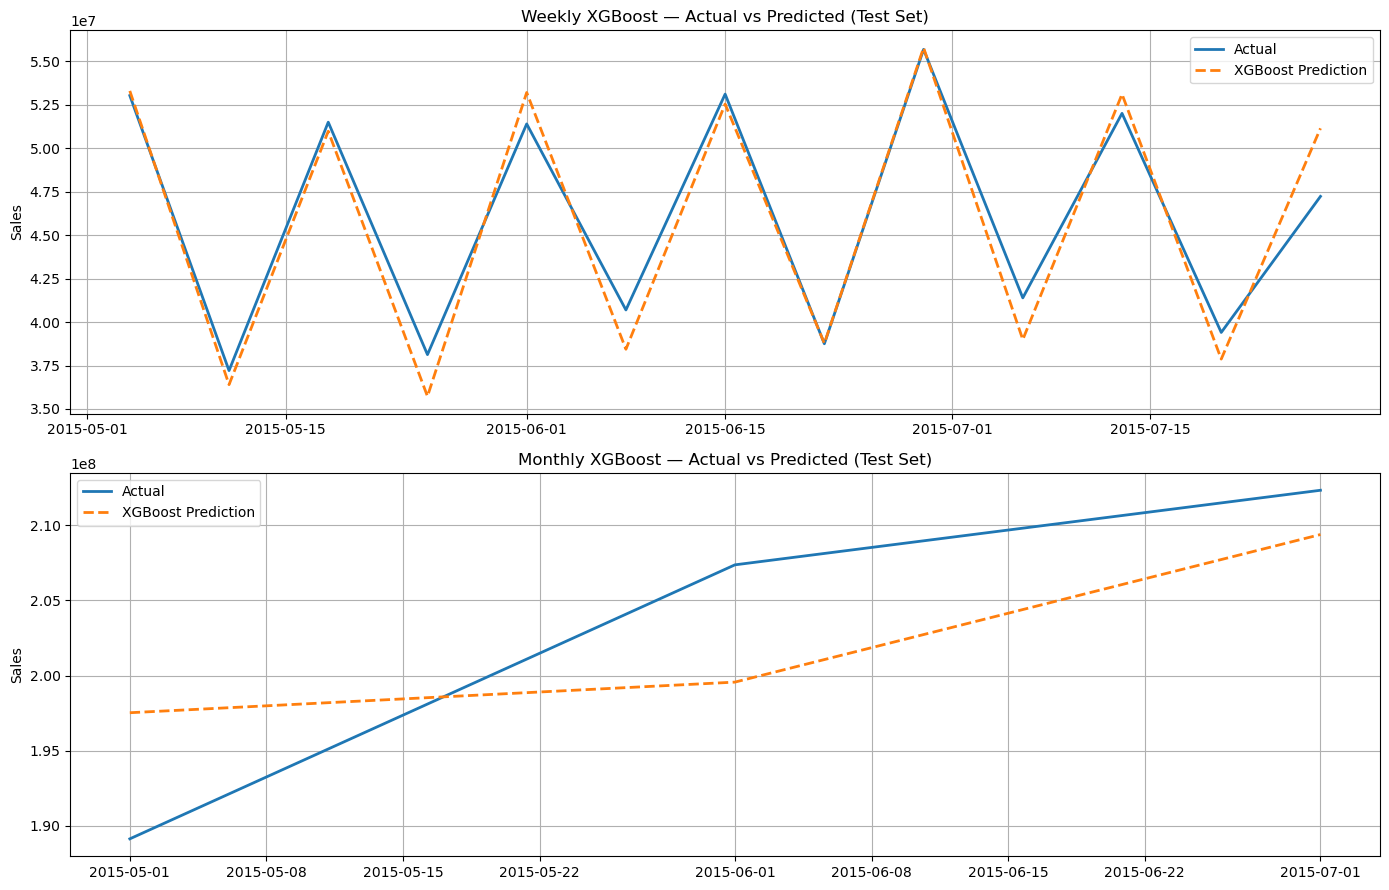

In [85]:
# Actual vs predicted sales for selected XGBoost models

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

plot_configs = [
    (
        axes[0],
        weekly_test_df,
        xgb_weekly_test_pred,
        "WeekStartDate",
        WEEKLY_TARGET,
        "Weekly XGBoost"
    ),
    (
        axes[1],
        monthly_test_df,
        xgb_monthly_test_pred,
        "MonthStartDate",
        MONTHLY_TARGET,
        "Monthly XGBoost"
    )
]

for ax, test_df, pred, date_col, sales_col, title in plot_configs:

    aggregated = (
        test_df
        .assign(Prediction=pred)
        .groupby(date_col)[[sales_col, "Prediction"]]
        .sum()
    )

    ax.plot(
        aggregated.index,
        aggregated[sales_col],
        label="Actual",
        linewidth=2
    )

    ax.plot(
        aggregated.index,
        aggregated["Prediction"],
        label="XGBoost Prediction",
        linewidth=2,
        linestyle="--"
    )

    ax.set_title(
        f"{title} — Actual vs Predicted (Test Set)"
    )
    ax.set_ylabel("Sales")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

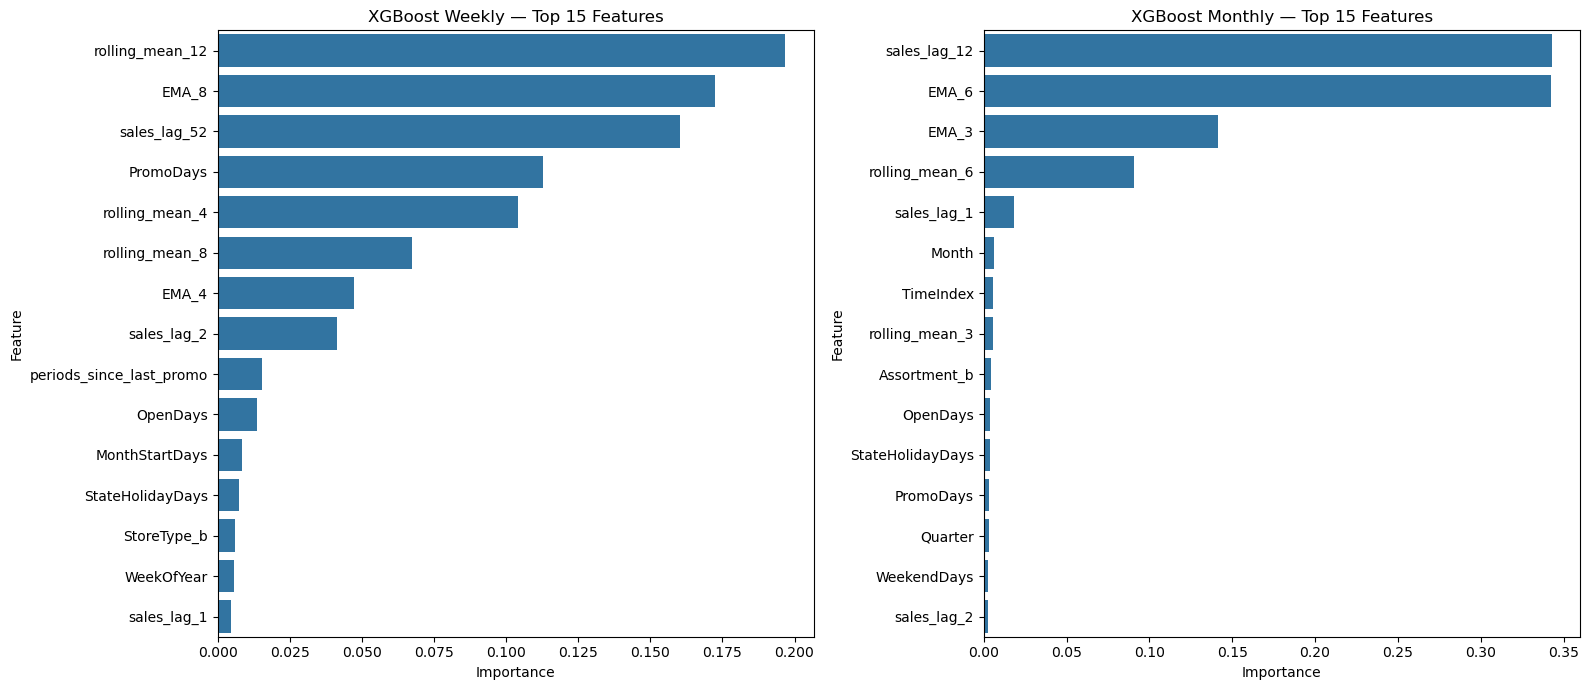

In [86]:
# XGBoost feature importance

xgb_weekly_importance = (
    pd.DataFrame({
        "Feature": weekly_features,
        "Importance": xgb_weekly_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

xgb_monthly_importance = (
    pd.DataFrame({
        "Feature": monthly_features,
        "Importance": xgb_monthly_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=xgb_weekly_importance.head(15),
    x="Importance",
    y="Feature",
    ax=axes[0]
)
axes[0].set_title("XGBoost Weekly — Top 15 Features")

sns.barplot(
    data=xgb_monthly_importance.head(15),
    x="Importance",
    y="Feature",
    ax=axes[1]
)
axes[1].set_title("XGBoost Monthly — Top 15 Features")

plt.tight_layout()
plt.show()

In [87]:
# Combine final XGBoost test results

xgb_results_df = pd.concat(
    [
        xgb_weekly_test_result,
        xgb_monthly_test_result
    ],
    ignore_index=True
)

display(xgb_results_df)

,Model,Forecast Type,Dataset,MAE,RMSE,MAPE,RMSPE
0,XGBoost,Weekly,Test,2173.826,3181.982,5.334,7.362
1,XGBoost,Monthly,Test,8462.312,11351.831,4.729,6.283


## 11. Final Model Comparison and Selection (RQ1)

The final test-set performance of the Moving Average baseline, Random Forest, and XGBoost models is compared using MAE, RMSE, MAPE, and RMSPE for both weekly and monthly forecasting.

Model development and hyperparameter selection were performed using validation-set MAE. The held-out test set is used only for the final unbiased comparison of model performance.

The model selected for the forecasting component of the DSS is based primarily on validation MAE, while the remaining metrics are used to provide a broader assessment of forecasting accuracy.

In [88]:
# Final held-out test-set comparison

comparison_columns = [
    "Model",
    "Forecast Type",
    "MAE",
    "RMSE",
    "MAPE",
    "RMSPE"
]

final_results_df = pd.concat(
    [
        baseline_results_df[comparison_columns],
        rf_results_df[comparison_columns],
        xgb_results_df[comparison_columns]
    ],
    ignore_index=True
)

# Arrange weekly and monthly results together
forecast_order = pd.CategoricalDtype(
    ["Weekly", "Monthly"],
    ordered=True
)

final_results_df["Forecast Type"] = (
    final_results_df["Forecast Type"]
    .astype(forecast_order)
)

final_results_df = (
    final_results_df
    .sort_values(
        ["Forecast Type", "MAE"]
    )
    .reset_index(drop=True)
)

final_results_df[
    ["MAE", "RMSE", "MAPE", "RMSPE"]
] = final_results_df[
    ["MAE", "RMSE", "MAPE", "RMSPE"]
].round(3)

display(final_results_df)

,Model,Forecast Type,MAE,RMSE,MAPE,RMSPE
0,XGBoost,Weekly,2173.826,3181.982,5.334,7.362
1,Random Forest,Weekly,2760.274,4164.140,6.674,9.627
2,Moving Average 12 Weeks,Weekly,6485.035,7511.622,16.499,19.266
3,XGBoost,Monthly,8462.312,11351.831,4.729,6.283
4,Random Forest,Monthly,9234.614,12643.827,5.224,7.987
5,Moving Average 6 Months,Monthly,12816.886,17083.914,7.109,9.717


In [89]:
## Final selected models based on validation MAE

selected_models = pd.DataFrame([
    {
        "Forecast Type": "Weekly",
        "Selected Model": "XGBoost",
        "Validation MAE": best_xgb_weekly_validation_mae
    },
    {
        "Forecast Type": "Monthly",
        "Selected Model": "XGBoost",
        "Validation MAE": xgb_monthly_tuning_df.iloc[0]["Validation_MAE"]
    }
])

selected_models["Validation MAE"] = (
    selected_models["Validation MAE"].round(3)
)

display(selected_models)

,Forecast Type,Selected Model,Validation MAE
0,Weekly,XGBoost,2642.298
1,Monthly,XGBoost,9352.965


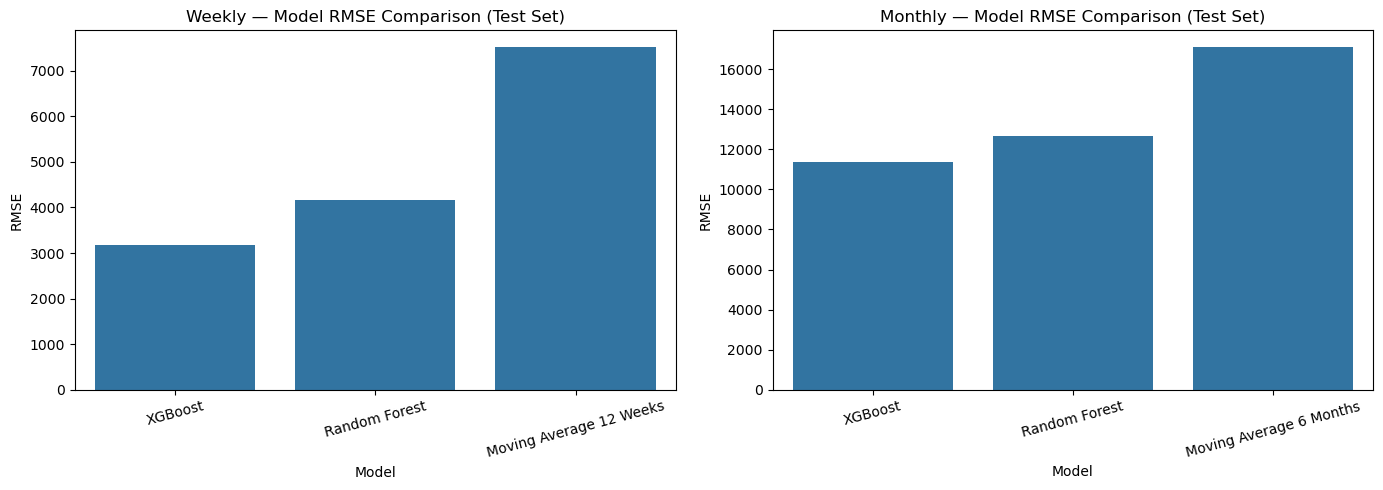

In [90]:
# Visual comparison of final test-set RMSE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, forecast_type in [
    (axes[0], "Weekly"),
    (axes[1], "Monthly")
]:
    subset = final_results_df[
        final_results_df["Forecast Type"] == forecast_type
    ]

    sns.barplot(
        data=subset,
        x="Model",
        y="RMSE",
        ax=ax
    )

    ax.set_title(
        f"{forecast_type} — Model RMSE Comparison (Test Set)"
    )
    ax.set_ylabel("RMSE")
    ax.tick_params(
        axis="x",
        rotation=15
    )

plt.tight_layout()
plt.show()

## 12. Explainability with SHAP

SHAP explanations are generated for the selected weekly and monthly XGBoost models to improve the interpretability of the forecasting system.

SHAP is used to provide:

- **Global explanations** — identifying which features contribute most strongly to model predictions overall.
- **Local explanations** — showing how individual features contribute to a specific forecast.

The SHAP explanations required by the DSS are precomputed and later exported as artifacts. This allows the backend to serve forecast explanations without calculating SHAP values at runtime.

In [91]:
import shap

# Create SHAP explainers for the selected XGBoost models
weekly_explainer = shap.TreeExplainer(
    xgb_weekly_model
)

monthly_explainer = shap.TreeExplainer(
    xgb_monthly_model
)

# Use a reproducible sample of up to 1000 test observations
# to keep global SHAP analysis computationally manageable.
weekly_sample_size = min(
    1000,
    len(X_weekly_test)
)

monthly_sample_size = min(
    1000,
    len(X_monthly_test)
)

X_weekly_shap_sample = X_weekly_test.sample(
    n=weekly_sample_size,
    random_state=42
)

X_monthly_shap_sample = X_monthly_test.sample(
    n=monthly_sample_size,
    random_state=42
)

# Calculate SHAP values
weekly_shap_values = weekly_explainer.shap_values(
    X_weekly_shap_sample
)

monthly_shap_values = monthly_explainer.shap_values(
    X_monthly_shap_sample
)

print(
    "Weekly SHAP values shape:",
    np.asarray(weekly_shap_values).shape
)

print(
    "Monthly SHAP values shape:",
    np.asarray(monthly_shap_values).shape
)

Weekly SHAP values shape: (1000, 45)
Monthly SHAP values shape: (1000, 41)


── Weekly XGBoost — Global SHAP Feature Importance ──


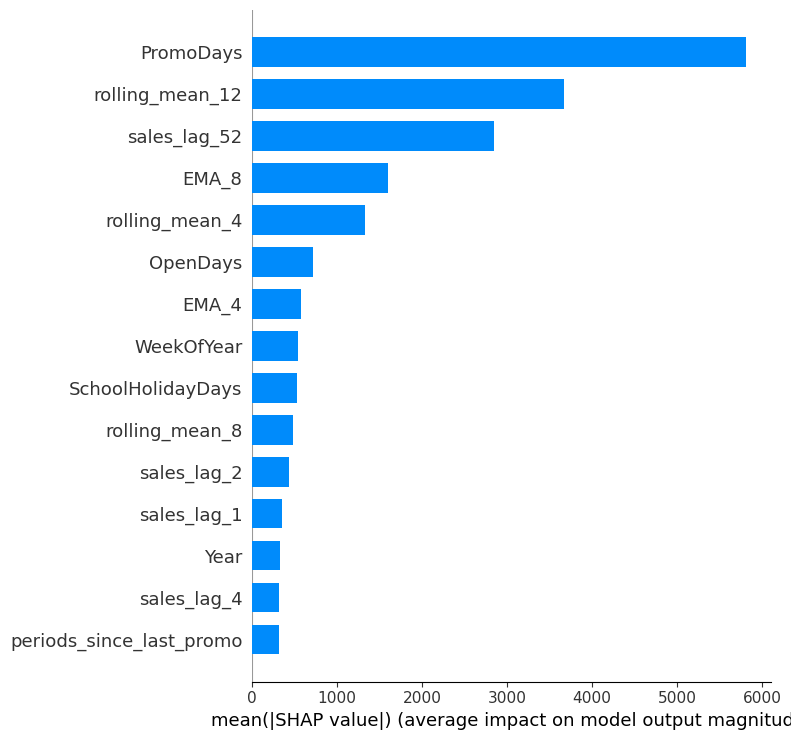


── Weekly XGBoost — SHAP Beeswarm ──


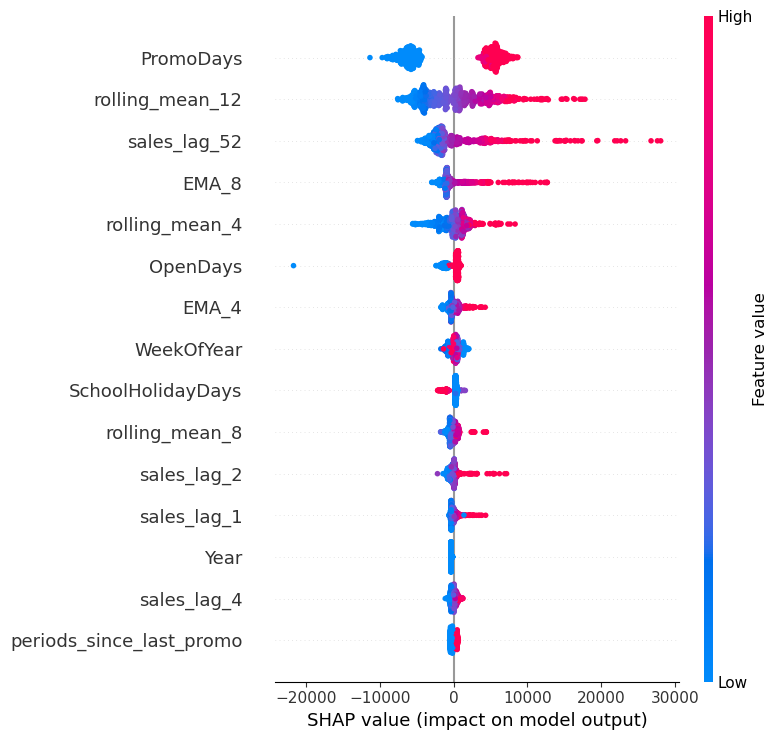

In [92]:
# Global SHAP explanations — Weekly XGBoost

print(
    "── Weekly XGBoost — Global SHAP Feature Importance ──"
)

shap.summary_plot(
    weekly_shap_values,
    X_weekly_shap_sample,
    plot_type="bar",
    max_display=15
)

print(
    "\n── Weekly XGBoost — SHAP Beeswarm ──"
)

shap.summary_plot(
    weekly_shap_values,
    X_weekly_shap_sample,
    max_display=15
)

── Monthly XGBoost — Global SHAP Feature Importance ──


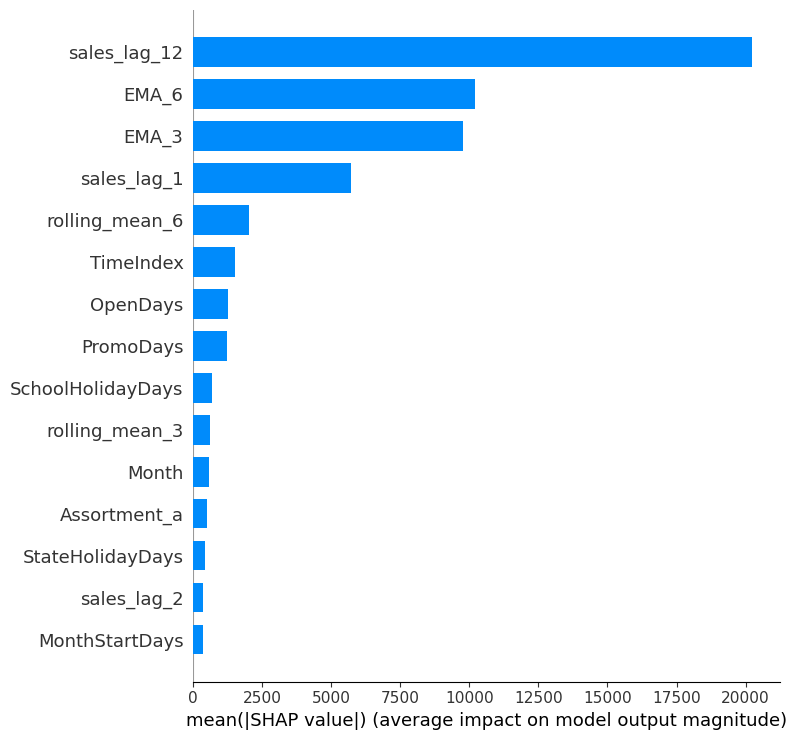


── Monthly XGBoost — SHAP Beeswarm ──


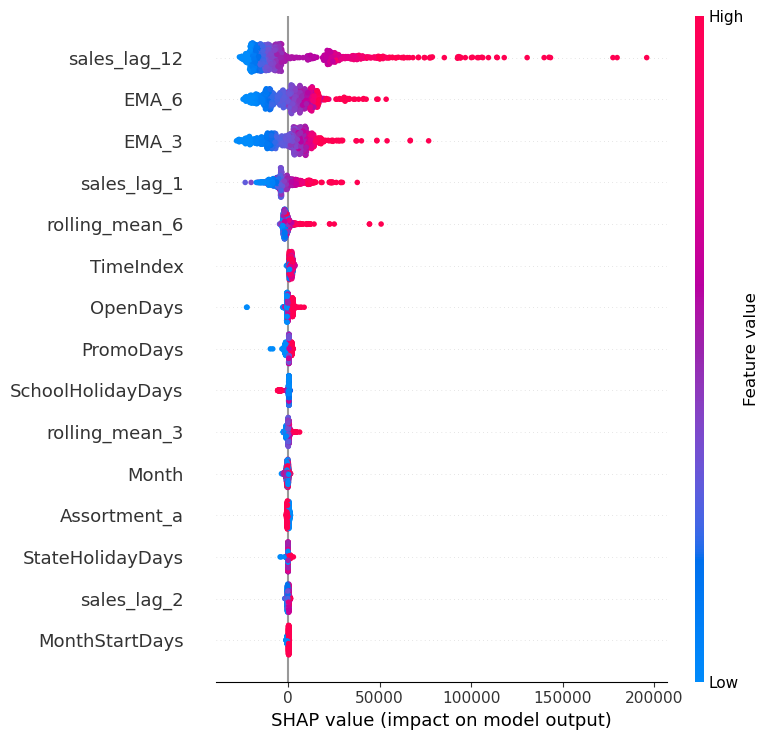

In [93]:
# Global SHAP explanations — Monthly XGBoost

print(
    "── Monthly XGBoost — Global SHAP Feature Importance ──"
)

shap.summary_plot(
    monthly_shap_values,
    X_monthly_shap_sample,
    plot_type="bar",
    max_display=15
)

print(
    "\n── Monthly XGBoost — SHAP Beeswarm ──"
)

shap.summary_plot(
    monthly_shap_values,
    X_monthly_shap_sample,
    max_display=15
)

In [94]:
# Local SHAP explanation — single weekly forecast

weekly_instance_index = X_weekly_shap_sample.index[0]

weekly_instance = X_weekly_test.loc[
    [weekly_instance_index]
]

weekly_actual = float(
    y_weekly_test.loc[weekly_instance_index]
)

weekly_prediction = float(
    xgb_weekly_model.predict(
        weekly_instance
    )[0]
)

# Retrieve identifying information for this forecast
weekly_store = weekly_test_df.loc[
    weekly_instance_index,
    "Store"
]

weekly_date = weekly_test_df.loc[
    weekly_instance_index,
    "WeekStartDate"
]

# Calculate SHAP values for this instance
weekly_instance_shap = np.asarray(
    weekly_explainer.shap_values(
        weekly_instance
    )
)[0]

weekly_local_explanation = pd.DataFrame({
    "Feature": weekly_instance.columns,
    "Feature Value": weekly_instance.iloc[0].values,
    "SHAP Value": weekly_instance_shap
})

# Describe direction of contribution
weekly_local_explanation["Effect"] = np.select(
    [
        weekly_local_explanation["SHAP Value"] > 0,
        weekly_local_explanation["SHAP Value"] < 0
    ],
    [
        "Increases prediction",
        "Decreases prediction"
    ],
    default="No effect"
)

# Rank features by absolute SHAP contribution
weekly_local_explanation = (
    weekly_local_explanation
    .assign(
        Abs_SHAP=lambda df: df["SHAP Value"].abs()
    )
    .sort_values(
        "Abs_SHAP",
        ascending=False
    )
    .drop(columns="Abs_SHAP")
    .reset_index(drop=True)
)

print(
    f"Store: {weekly_store} | "
    f"Week: {weekly_date:%Y-%m-%d}"
)

print(
    f"Actual: {weekly_actual:,.0f} | "
    f"Predicted: {weekly_prediction:,.0f}"
)

display(
    weekly_local_explanation.head(15)
)

Store: 671 | Week: 2015-06-01
Actual: 39,971 | Predicted: 41,856


,Feature,Feature Value,SHAP Value,Effect
0,PromoDays,4.000000,4637.947266,Increases prediction
1,sales_lag_52,32247.000000,-1673.099487,Decreases prediction
2,OpenDays,5.000000,-1485.862305,Decreases prediction
3,EMA_8,37401.913725,-990.402100,Decreases prediction
4,SchoolHolidayDays,4.000000,-847.584412,Decreases prediction
5,WeekOfYear,23.000000,768.150635,Increases prediction
6,MonthStartDays,1.000000,611.022583,Increases prediction
7,periods_since_last_promo,1.000000,487.827759,Increases prediction
8,EMA_4,36220.442197,-416.851044,Decreases prediction
9,sales_lag_1,29375.000000,-415.283630,Decreases prediction


In [95]:
# Local SHAP explanation — single monthly forecast

monthly_instance_index = X_monthly_shap_sample.index[0]

monthly_instance = X_monthly_test.loc[
    [monthly_instance_index]
]

monthly_actual = float(
    y_monthly_test.loc[monthly_instance_index]
)

monthly_prediction = float(
    xgb_monthly_model.predict(
        monthly_instance
    )[0]
)

# Retrieve identifying information
monthly_store = monthly_test_df.loc[
    monthly_instance_index,
    "Store"
]

monthly_date = monthly_test_df.loc[
    monthly_instance_index,
    "MonthStartDate"
]

# Calculate SHAP values
monthly_instance_shap = np.asarray(
    monthly_explainer.shap_values(
        monthly_instance
    )
)[0]

monthly_local_explanation = pd.DataFrame({
    "Feature": monthly_instance.columns,
    "Feature Value": monthly_instance.iloc[0].values,
    "SHAP Value": monthly_instance_shap
})

# Direction of contribution
monthly_local_explanation["Effect"] = np.select(
    [
        monthly_local_explanation["SHAP Value"] > 0,
        monthly_local_explanation["SHAP Value"] < 0
    ],
    [
        "Increases prediction",
        "Decreases prediction"
    ],
    default="No effect"
)

# Rank by absolute SHAP contribution
monthly_local_explanation = (
    monthly_local_explanation
    .assign(
        Abs_SHAP=lambda df: df["SHAP Value"].abs()
    )
    .sort_values(
        "Abs_SHAP",
        ascending=False
    )
    .drop(columns="Abs_SHAP")
    .reset_index(drop=True)
)

print(
    f"Store: {monthly_store} | "
    f"Month: {monthly_date:%Y-%m}"
)

print(
    f"Actual: {monthly_actual:,.0f} | "
    f"Predicted: {monthly_prediction:,.0f}"
)

display(
    monthly_local_explanation.head(15)
)

Store: 352 | Month: 2015-05
Actual: 160,502 | Predicted: 170,406


,Feature,Feature Value,SHAP Value,Effect
0,sales_lag_12,164362.000000,-9726.003906,Decreases prediction
1,EMA_3,166963.552194,3209.196289,Increases prediction
2,EMA_6,168394.964003,2679.182617,Increases prediction
3,sales_lag_1,168228.000000,-2518.309082,Decreases prediction
4,TimeIndex,29.000000,2242.510010,Increases prediction
5,PromoDays,10.000000,-1635.135864,Decreases prediction
6,Month,5.000000,-824.181030,Decreases prediction
7,OpenDays,23.000000,-694.006897,Decreases prediction
8,Assortment_a,0.000000,677.676880,Increases prediction
9,MonthStartDays,0.000000,-615.952515,Decreases prediction


## 13. DSS Forecast Output Preparation

The selected XGBoost forecasts and SHAP explanations are transformed into DSS-ready records for use by the FastAPI backend.

Each record contains:

- Store identifier
- Forecast period
- Predicted sales
- Most influential positive SHAP factors
- Most influential negative SHAP factors

These precomputed forecasting and explainability outputs allow the backend to serve predictions without retraining the models or recalculating SHAP values at runtime.

The AI recommendation component can use the forecast and explanation information to generate business-oriented recommendations for the user.

In [96]:
# Readable feature names for DSS explanations

feature_name_map = {
    "PromoDays": "promotion activity",
    "OpenDays": "number of open days",
    "SchoolHolidayDays": "school holiday period",
    "StateHolidayDays": "state holiday period",
    "WeekendDays": "weekend days",
    "MonthStartDays": "month-start timing",
    "MonthEndDays": "month-end timing",

    "periods_since_last_promo": "time since previous promotion",

    # Lag features
    "sales_lag_1": "previous period sales",
    "sales_lag_2": "sales two periods ago",
    "sales_lag_3": "sales three months ago",
    "sales_lag_4": "sales four weeks ago",
    "sales_lag_8": "sales eight weeks ago",
    "sales_lag_12": "sales twelve months ago",
    "sales_lag_52": "sales fifty-two weeks ago",

    # Rolling features
    "rolling_mean_3": "recent 3-month average sales",
    "rolling_mean_4": "recent 4-week average sales",
    "rolling_mean_6": "recent 6-month average sales",
    "rolling_mean_8": "recent 8-week average sales",
    "rolling_mean_12": "recent 12-week average sales",

    "rolling_std_3": "recent 3-month sales variability",
    "rolling_std_4": "recent 4-week sales variability",
    "rolling_std_6": "recent 6-month sales variability",
    "rolling_std_8": "recent 8-week sales variability",
    "rolling_std_12": "recent 12-week sales variability",

    # EMA features
    "EMA_3": "recent 3-month weighted sales trend",
    "EMA_4": "recent 4-week weighted sales trend",
    "EMA_6": "recent 6-month weighted sales trend",
    "EMA_8": "recent 8-week weighted sales trend",

    # Calendar and store features
    "TimeIndex": "time progression",
    "Year": "calendar year",
    "Month": "month of year",
    "WeekOfYear": "week of year",
    "Quarter": "quarter of year",

    "CompetitionDistance": "distance to nearest competitor",
    "CompetitionOpenKnown": "competition opening date availability",
    "Promo2": "long-term promotion participation"
}

In [97]:
def extract_positive_negative_factors(local_exp_df, top_n=3):
    """
    Return the strongest positive and negative SHAP factors
    ranked by absolute contribution magnitude.
    """

    positive = (
        local_exp_df[
            local_exp_df["SHAP Value"] > 0
        ]
        .assign(
            Abs_SHAP=lambda df: df["SHAP Value"].abs()
        )
        .sort_values(
            "Abs_SHAP",
            ascending=False
        )
        .head(top_n)
    )

    negative = (
        local_exp_df[
            local_exp_df["SHAP Value"] < 0
        ]
        .assign(
            Abs_SHAP=lambda df: df["SHAP Value"].abs()
        )
        .sort_values(
            "Abs_SHAP",
            ascending=False
        )
        .head(top_n)
    )

    def readable(df_):
        return [
            feature_name_map.get(
                row["Feature"],
                row["Feature"]
            )
            for _, row in df_.iterrows()
        ]

    return readable(positive), readable(negative)


def create_forecast_summary(
    predicted_sales,
    positive_factors,
    negative_factors,
    forecast_type
):
    """
    Create a factual forecast summary for the DSS.
    Business recommendations are generated separately
    by the AI recommendation component.
    """

    parts = [
        f"{forecast_type} predicted sales: "
        f"{predicted_sales:,.0f}."
    ]

    if positive_factors:
        parts.append(
            "Main factors increasing the model prediction: "
            + ", ".join(positive_factors)
            + "."
        )

    if negative_factors:
        parts.append(
            "Main factors decreasing the model prediction: "
            + ", ".join(negative_factors)
            + "."
        )

    return " ".join(parts)

In [98]:
# Sample DSS-ready forecast records

# Weekly example
weekly_pos, weekly_neg = extract_positive_negative_factors(
    weekly_local_explanation,
    top_n=3
)

weekly_forecast_summary = create_forecast_summary(
    weekly_prediction,
    weekly_pos,
    weekly_neg,
    "Weekly"
)

weekly_dss_output = pd.DataFrame([{
    "Store": weekly_test_df.loc[
        weekly_instance_index,
        "Store"
    ],
    "Period": str(
        weekly_test_df.loc[
            weekly_instance_index,
            "WeekStartDate"
        ]
    )[:10],
    "Forecast Type": "Weekly",
    "Predicted Sales": round(
        weekly_prediction,
        2
    ),
    "Important Positive Factors": ", ".join(
        weekly_pos
    ),
    "Important Negative Factors": ", ".join(
        weekly_neg
    ),
    "Forecast Summary": weekly_forecast_summary
}])


# Monthly example
monthly_pos, monthly_neg = extract_positive_negative_factors(
    monthly_local_explanation,
    top_n=3
)

monthly_forecast_summary = create_forecast_summary(
    monthly_prediction,
    monthly_pos,
    monthly_neg,
    "Monthly"
)

monthly_dss_output = pd.DataFrame([{
    "Store": monthly_test_df.loc[
        monthly_instance_index,
        "Store"
    ],
    "Period": str(
        monthly_test_df.loc[
            monthly_instance_index,
            "MonthStartDate"
        ]
    )[:10],
    "Forecast Type": "Monthly",
    "Predicted Sales": round(
        monthly_prediction,
        2
    ),
    "Important Positive Factors": ", ".join(
        monthly_pos
    ),
    "Important Negative Factors": ", ".join(
        monthly_neg
    ),
    "Forecast Summary": monthly_forecast_summary
}])


# Combine sample weekly and monthly DSS records
dss_output_sample = pd.concat(
    [
        weekly_dss_output,
        monthly_dss_output
    ],
    ignore_index=True
)

display(dss_output_sample)

,Store,Period,Forecast Type,Predicted Sales,Important Positive Factors,Important Negative Factors,Forecast Summary
0,671,2015-06-01,Weekly,41855.74,"promotion activity, week of year, month-start ...","sales fifty-two weeks ago, number of open days...","Weekly predicted sales: 41,856. Main factors i..."
1,352,2015-05-01,Monthly,170405.69,"recent 3-month weighted sales trend, recent 6-...","sales twelve months ago, previous period sales...","Monthly predicted sales: 170,406. Main factors..."


In [99]:
def build_full_dss_output(
    test_df,
    predictions,
    explainer,
    features,
    date_col,
    forecast_type,
    top_n=3
):
    """
    Build DSS-ready forecast records for all test observations.

    Actual sales are intentionally excluded because they would not
    be available when serving a real future forecast.
    """

    X = test_df[features]

    # Calculate SHAP values for all observations in one batch
    shap_values = np.asarray(
        explainer.shap_values(X)
    )

    rows = []

    for position, (_, row) in enumerate(test_df.iterrows()):

        local_exp = pd.DataFrame({
            "Feature": features,
            "SHAP Value": shap_values[position]
        })

        positive_factors, negative_factors = (
            extract_positive_negative_factors(
                local_exp,
                top_n=top_n
            )
        )

        predicted_sales = float(
            predictions[position]
        )

        forecast_summary = create_forecast_summary(
            predicted_sales,
            positive_factors,
            negative_factors,
            forecast_type
        )

        rows.append({
            "Store": int(row["Store"]),
            "Period": str(row[date_col])[:10],
            "Forecast Type": forecast_type,
            "Predicted Sales": round(predicted_sales, 2),
            "Important Positive Factors":
                ", ".join(positive_factors),
            "Important Negative Factors":
                ", ".join(negative_factors),
            "Forecast Summary": forecast_summary
        })

    return pd.DataFrame(rows)

In [100]:
# Build DSS-ready output for all held-out forecast records

print("Building weekly DSS output for all stores...")

weekly_dss_full = build_full_dss_output(
    test_df=weekly_test_df,
    predictions=xgb_weekly_test_pred,
    explainer=weekly_explainer,
    features=weekly_features,
    date_col="WeekStartDate",
    forecast_type="Weekly"
)

print("Building monthly DSS output for all stores...")

monthly_dss_full = build_full_dss_output(
    test_df=monthly_test_df,
    predictions=xgb_monthly_test_pred,
    explainer=monthly_explainer,
    features=monthly_features,
    date_col="MonthStartDate",
    forecast_type="Monthly"
)

dss_output_full = pd.concat(
    [
        weekly_dss_full,
        monthly_dss_full
    ],
    ignore_index=True
)

print(
    f"Total DSS rows : {len(dss_output_full)}"
)
print(
    f"Weekly rows    : {len(weekly_dss_full)}"
)
print(
    f"Monthly rows   : {len(monthly_dss_full)}"
)

display(dss_output_full.head())

Building weekly DSS output for all stores...
Building monthly DSS output for all stores...
Total DSS rows : 17832
Weekly rows    : 14487
Monthly rows   : 3345


,Store,Period,Forecast Type,Predicted Sales,Important Positive Factors,Important Negative Factors,Forecast Summary
0,1,2015-05-04,Weekly,29789.13,"promotion activity, week of year, school holid...","recent 12-week average sales, recent 4-week av...","Weekly predicted sales: 29,789. Main factors i..."
1,1,2015-05-11,Weekly,21099.62,"recent 12-week sales variability, school holid...","promotion activity, recent 12-week average sal...","Weekly predicted sales: 21,100. Main factors i..."
2,1,2015-05-18,Weekly,28515.30,"promotion activity, school holiday period, num...","recent 12-week average sales, recent 4-week av...","Weekly predicted sales: 28,515. Main factors i..."
3,1,2015-05-25,Weekly,19732.88,"week of year, school holiday period, recent 12...","promotion activity, recent 12-week average sal...","Weekly predicted sales: 19,733. Main factors i..."
4,1,2015-06-01,Weekly,27414.00,"promotion activity, week of year, month-start ...","recent 12-week average sales, recent 4-week av...","Weekly predicted sales: 27,414. Main factors i..."


In [101]:
def build_full_local_shap(
    test_df,
    explainer,
    features,
    date_col,
    forecast_type
):
    """
    Build feature-level local SHAP explanations
    for every forecast observation.
    """

    X = test_df[features]

    # Calculate SHAP values for all observations in one batch
    shap_values = np.asarray(
        explainer.shap_values(X)
    )

    n_rows = len(test_df)
    n_features = len(features)

    local_shap_df = pd.DataFrame({
        "Store": np.repeat(
            test_df["Store"].to_numpy(),
            n_features
        ),

        "Period": np.repeat(
            test_df[date_col]
            .astype(str)
            .str[:10]
            .to_numpy(),
            n_features
        ),

        "Forecast Type": np.repeat(
            forecast_type,
            n_rows * n_features
        ),

        "Feature": np.tile(
            features,
            n_rows
        ),

        "Feature Value": X.to_numpy().reshape(-1),

        "SHAP Value": shap_values.reshape(-1)
    })

    # Add readable feature names
    local_shap_df["Readable Feature"] = (
        local_shap_df["Feature"]
        .map(feature_name_map)
        .fillna(local_shap_df["Feature"])
    )

    # Direction of SHAP contribution
    local_shap_df["Effect"] = np.select(
        [
            local_shap_df["SHAP Value"] > 0,
            local_shap_df["SHAP Value"] < 0
        ],
        [
            "Increases prediction",
            "Decreases prediction"
        ],
        default="No effect"
    )

    local_shap_df["Feature Value"] = (
        local_shap_df["Feature Value"].round(4)
    )

    local_shap_df["SHAP Value"] = (
        local_shap_df["SHAP Value"].round(4)
    )

    return local_shap_df


print("build_full_local_shap defined.")

build_full_local_shap defined.


In [102]:
# Full local SHAP explanations for all forecast records

print("Building weekly local SHAP for all stores...")

weekly_local_shap_full = build_full_local_shap(
    weekly_test_df,
    weekly_explainer,
    weekly_features,
    "WeekStartDate",
    "Weekly"
)

print("Building monthly local SHAP for all stores...")

monthly_local_shap_full = build_full_local_shap(
    monthly_test_df,
    monthly_explainer,
    monthly_features,
    "MonthStartDate",
    "Monthly"
)

print(
    f"Weekly local SHAP rows : {len(weekly_local_shap_full)}"
)

print(
    f"Monthly local SHAP rows: {len(monthly_local_shap_full)}"
)

display(
    weekly_local_shap_full.head(5)
)

Building weekly local SHAP for all stores...
Building monthly local SHAP for all stores...
Weekly local SHAP rows : 651915
Monthly local SHAP rows: 137145


,Store,Period,Forecast Type,Feature,Feature Value,SHAP Value,Readable Feature,Effect
0,1,2015-05-04,Weekly,Store,1.0,18.673100,Store,Increases prediction
1,1,2015-05-04,Weekly,WeekOfYear,19.0,1284.895508,week of year,Increases prediction
2,1,2015-05-04,Weekly,OpenDays,6.0,344.763489,number of open days,Increases prediction
3,1,2015-05-04,Weekly,PromoDays,5.0,4400.222656,promotion activity,Increases prediction
4,1,2015-05-04,Weekly,SchoolHolidayDays,0.0,345.277802,school holiday period,Increases prediction


## 14. Saving Final Artefacts for FastAPI / DSS Integration

The final trained models, feature definitions, forecasting outputs, explainability results, evaluation results, and supporting metadata are saved as deployment artefacts for integration with the FastAPI backend and DSS.

Only final artefacts required for model evaluation, explainability, and system integration are exported in this section.

In [103]:
# Final artefact export

artifact_dir = Path("model_artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)


# =========================================================
# 1. Selected XGBoost models
# =========================================================

joblib.dump(
    xgb_weekly_model,
    artifact_dir / "xgb_weekly_model.pkl"
)

joblib.dump(
    xgb_monthly_model,
    artifact_dir / "xgb_monthly_model.pkl"
)


# =========================================================
# 2. Model feature definitions
# =========================================================

joblib.dump(
    weekly_features,
    artifact_dir / "weekly_feature_columns.pkl"
)

joblib.dump(
    monthly_features,
    artifact_dir / "monthly_feature_columns.pkl"
)


# =========================================================
# 3. Final test-set predictions for evaluation
# Actual Sales are retained here only for thesis evaluation.
# They are not included in the DSS/AI input.
# =========================================================

weekly_prediction_output = weekly_test_df[
    ["Store", "WeekStartDate", WEEKLY_TARGET]
].copy()

weekly_prediction_output = weekly_prediction_output.rename(
    columns={
        "WeekStartDate": "Period",
        WEEKLY_TARGET: "Actual Sales"
    }
)

weekly_prediction_output["Forecast Type"] = "Weekly"

weekly_prediction_output["Predicted Sales"] = (
    xgb_weekly_test_pred
)

weekly_prediction_output = weekly_prediction_output[
    [
        "Store",
        "Period",
        "Forecast Type",
        "Actual Sales",
        "Predicted Sales"
    ]
]


monthly_prediction_output = monthly_test_df[
    ["Store", "MonthStartDate", MONTHLY_TARGET]
].copy()

monthly_prediction_output = monthly_prediction_output.rename(
    columns={
        "MonthStartDate": "Period",
        MONTHLY_TARGET: "Actual Sales"
    }
)

monthly_prediction_output["Forecast Type"] = "Monthly"

monthly_prediction_output["Predicted Sales"] = (
    xgb_monthly_test_pred
)

monthly_prediction_output = monthly_prediction_output[
    [
        "Store",
        "Period",
        "Forecast Type",
        "Actual Sales",
        "Predicted Sales"
    ]
]


weekly_prediction_output.to_csv(
    artifact_dir / "weekly_test_predictions.csv",
    index=False
)

monthly_prediction_output.to_csv(
    artifact_dir / "monthly_test_predictions.csv",
    index=False
)


# =========================================================
# 4. Global SHAP summaries
# =========================================================

weekly_global_shap_summary = pd.DataFrame({
    "Feature": weekly_features,
    "Mean Absolute SHAP": np.abs(
        np.asarray(weekly_shap_values)
    ).mean(axis=0)
})

weekly_global_shap_summary["Readable Feature"] = (
    weekly_global_shap_summary["Feature"]
    .map(feature_name_map)
    .fillna(weekly_global_shap_summary["Feature"])
)

weekly_global_shap_summary = (
    weekly_global_shap_summary
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


monthly_global_shap_summary = pd.DataFrame({
    "Feature": monthly_features,
    "Mean Absolute SHAP": np.abs(
        np.asarray(monthly_shap_values)
    ).mean(axis=0)
})

monthly_global_shap_summary["Readable Feature"] = (
    monthly_global_shap_summary["Feature"]
    .map(feature_name_map)
    .fillna(monthly_global_shap_summary["Feature"])
)

monthly_global_shap_summary = (
    monthly_global_shap_summary
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


weekly_global_shap_summary.to_csv(
    artifact_dir / "weekly_global_shap_importance.csv",
    index=False
)

monthly_global_shap_summary.to_csv(
    artifact_dir / "monthly_global_shap_importance.csv",
    index=False
)


# =========================================================
# 5. Full local SHAP explanations
# =========================================================

weekly_local_shap_full.to_csv(
    artifact_dir / "weekly_local_shap_explanation.csv",
    index=False
)

monthly_local_shap_full.to_csv(
    artifact_dir / "monthly_local_shap_explanation.csv",
    index=False
)


# =========================================================
# 6. Selected XGBoost feature importance
# =========================================================

xgb_weekly_importance.to_csv(
    artifact_dir / "xgb_weekly_feature_importance.csv",
    index=False
)

xgb_monthly_importance.to_csv(
    artifact_dir / "xgb_monthly_feature_importance.csv",
    index=False
)


# =========================================================
# 7. Final model evaluation
# =========================================================

final_results_df.to_csv(
    artifact_dir / "final_model_comparison.csv",
    index=False
)

selected_models.to_csv(
    artifact_dir / "selected_models.csv",
    index=False
)


# =========================================================
# 8. DSS-ready forecast output
# =========================================================

dss_output_full.to_csv(
    artifact_dir / "dss_forecast_output.csv",
    index=False
)


print("Final artefacts saved to:", artifact_dir)

print("\nSaved:")
for file_path in sorted(artifact_dir.iterdir()):
    print(" -", file_path.name)

Final artefacts saved to: model_artifacts

Saved:
 - dss_forecast_output.csv
 - final_model_comparison.csv
 - monthly_feature_columns.pkl
 - monthly_global_shap_importance.csv
 - monthly_local_shap_explanation.csv
 - monthly_test_predictions.csv
 - selected_models.csv
 - weekly_feature_columns.pkl
 - weekly_global_shap_importance.csv
 - weekly_local_shap_explanation.csv
 - weekly_test_predictions.csv
 - xgb_monthly_feature_importance.csv
 - xgb_monthly_model.pkl
 - xgb_weekly_feature_importance.csv
 - xgb_weekly_model.pkl


In [104]:
# Model metadata — human-readable and API-consumable

weekly_metrics_row = xgb_weekly_test_result.iloc[0]
monthly_metrics_row = xgb_monthly_test_result.iloc[0]

model_metadata = {
    "project_title": (
        "Explainable Sales Forecasting with AI-Generated "
        "Retail Recommendations: A Rossmann Case Study"
    ),

    "dataset": "Rossmann Store Sales",

    "forecasting": {
        "weekly": {
            "selected_model": "XGBoost",
            "target": WEEKLY_TARGET,
            "feature_count": len(weekly_features),

            "validation_mae": round(
                float(best_xgb_weekly_validation_mae),
                3
            ),

            "test_metrics": {
                "MAE": round(float(weekly_metrics_row["MAE"]), 3),
                "RMSE": round(float(weekly_metrics_row["RMSE"]), 3),
                "MAPE": round(float(weekly_metrics_row["MAPE"]), 3),
                "RMSPE": round(float(weekly_metrics_row["RMSPE"]), 3)
            }
        },

        "monthly": {
            "selected_model": "XGBoost",
            "target": MONTHLY_TARGET,
            "feature_count": len(monthly_features),

            "validation_mae": round(
                float(
                    xgb_monthly_tuning_df.iloc[0][
                        "Validation_MAE"
                    ]
                ),
                3
            ),

            "test_metrics": {
                "MAE": round(float(monthly_metrics_row["MAE"]), 3),
                "RMSE": round(float(monthly_metrics_row["RMSE"]), 3),
                "MAPE": round(float(monthly_metrics_row["MAPE"]), 3),
                "RMSPE": round(float(monthly_metrics_row["RMSPE"]), 3)
            }
        }
    },

    "model_selection": {
        "primary_metric": "Validation MAE",
        "test_set_use": "Final evaluation only"
    },

    "explainability": [
        "XGBoost feature importance",
        "Global SHAP importance",
        "Local SHAP explanations"
    ],

    "architecture": {
        "artifact_first": True,
        "runtime_retraining": False,
        "backend": "FastAPI",
        "frontend": "React",
        "ai_recommendations": True
    },

    "dss_output": {
        "contains_actual_sales": False,
        "contains_predicted_sales": True,
        "contains_shap_factors": True,
        "contains_forecast_summary": True
    }
}


# Save metadata
with open(
    artifact_dir / "model_metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        model_metadata,
        f,
        indent=2
    )


print("Saved model_metadata.json")


print("\nAll artefact files:")

for file_path in sorted(
    artifact_dir.iterdir()
):
    print(" -", file_path.name)

Saved model_metadata.json

All artefact files:
 - dss_forecast_output.csv
 - final_model_comparison.csv
 - model_metadata.json
 - monthly_feature_columns.pkl
 - monthly_global_shap_importance.csv
 - monthly_local_shap_explanation.csv
 - monthly_test_predictions.csv
 - selected_models.csv
 - weekly_feature_columns.pkl
 - weekly_global_shap_importance.csv
 - weekly_local_shap_explanation.csv
 - weekly_test_predictions.csv
 - xgb_monthly_feature_importance.csv
 - xgb_monthly_model.pkl
 - xgb_weekly_feature_importance.csv
 - xgb_weekly_model.pkl


In [105]:
import shutil

archive_path = shutil.make_archive(
    "rossmann_dss_model_artifacts",
    "zip",
    artifact_dir
)

print(
    "Created rossmann_dss_model_artifacts.zip "
    "containing the final model and DSS artefacts."
)

Created rossmann_dss_model_artifacts.zip containing the final model and DSS artefacts.
